<a id="p1"></a>
# Homework 2 
By Adascalitei Ana-Maria
1241EA

# I. Introduction

## Problem Definition

Online learning platforms often face low course completion rates. Predicting whether a student will complete a course helps identify at-risk learners early, support targeted interventions, and improve retention and learning outcomes.  
This project focuses on **predicting student course completion** using demographic, behavioral, and engagement data.

## Objectives

- Perform exploratory data analysis (EDA)
- Preprocess data (missing values, outliers, encoding, scaling)
- Apply PCA for dimensionality reduction
- Address class imbalance (SMOTE, undersampling)
- Train and evaluate multiple machine learning models
- Use cross-validation for robust evaluation
- Compare models using Accuracy, F1-score, Recall, and ROC-AUC

## Dataset Overview

- **Samples**: 100,000 students  
- **Features**: 43  
- **Target variable**: `Completed` (binary)  

### Key Challenges
- Class imbalance  
- Missing values  
- High dimensionality  
- Mixed data types and outliers


<a id="p3"></a>

# II. Exploratory Data Analysis (EDA)
## Insights from data exploration, including plots and correlations


## II.a. Describe the structure of the data: number of rows, columns, and data types
First we import all the libraries we will be using for this project

In [158]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', 43) # to see al the columns for better visualisation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from scipy import stats
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import time

Then we read the data and put it in the 'demographic'

In [2]:
demographic = pd.read_csv("data.csv")
#see the no of rows and columns (rows, columns)
demographic.shape 

(100000, 43)

After this, in order to describe the data we will use:

i. `.shape`  
→ to see the number of (rows, columns)

ii. `.columns`  
→ see all the feature columns we have

iii. `.head(10)`  
→ to see how our Data Frame looks like

iv. `.info()`  
→ summarize number of non-null values in each column, data type of each column and memory usage

v. `select_dtypes("number").head()`  
→ see only the columns that have numbers as values

vi. at the end, a new column was added for the **Completed** column (that already exists) and made numeric:  
→ **1 → Completed**, **0 → Not Completed**


In [3]:
# see the name of each column
demographic.columns

Index(['Name', 'Project_Grade', 'Enrollment_Date', 'Procrastination_Index',
       'Completed', 'Notifications_Checked', 'Average_Session_Duration_Min',
       'Discussion_Participation', 'Age', 'Payment_Amount',
       'Peer_Interaction_Score', 'App_Usage_Percentage', 'Quiz_Attempts',
       'Reminder_Emails_Clicked', 'Fee_Paid', 'Device_Type',
       'Support_Tickets_Raised', 'Days_Since_Last_Login', 'Course_Name',
       'Assignments_Missed', 'Rewatch_Count', 'Gender', 'Satisfaction_Rating',
       'Quiz_Score_Avg', 'Discount_Used', 'Login_Frequency',
       'Time_Spent_Hours', 'Total_Minutes_Est', 'Internet_Connection_Quality',
       'Course_Level', 'Employment_Status', 'Instructor_Rating', 'Student_ID',
       'Progress_Percentage', 'Education_Level', 'Course_Duration_Days',
       'Course_ID', 'Engagement_Score', 'Assignments_Submitted', 'City',
       'Video_Completion_Rate', 'Category', 'Payment_Mode'],
      dtype='object')

In [4]:
# see how the data looks like
demographic.head(10)

,Name,Project_Grade,Enrollment_Date,Procrastination_Index,Completed,Notifications_Checked,Average_Session_Duration_Min,Discussion_Participation,Age,Payment_Amount,Peer_Interaction_Score,App_Usage_Percentage,Quiz_Attempts,Reminder_Emails_Clicked,Fee_Paid,Device_Type,Support_Tickets_Raised,Days_Since_Last_Login,Course_Name,Assignments_Missed,Rewatch_Count,Gender,Satisfaction_Rating,Quiz_Score_Avg,Discount_Used,Login_Frequency,Time_Spent_Hours,Total_Minutes_Est,Internet_Connection_Quality,Course_Level,Employment_Status,Instructor_Rating,Student_ID,Progress_Percentage,Education_Level,Course_Duration_Days,Course_ID,Engagement_Score,Assignments_Submitted,City,Video_Completion_Rate,Category,Payment_Mode
0,Vihaan Patel,71.2,1/6/2024,2.44,Completed,6,30.0,2,19,1740,4.3,49,5,3,No,Laptop,4,1.0,Data Analysis with Python,1,0,Male,3.5,80.9,No,3.0,0.5,30.0,Medium,Intermediate,Student,4.7,STU100000,70.8,Diploma,60,C102,49.17,8,Indore,55.0,Programming,Scholarship
1,Arjun Nair,42.5,27-04-2025,12.64,Not Completed,5,37.0,2,17,6147,7.8,86,3,0,Yes,NaN,0,3.0,Machine Learning A-Z,6,2,Female,4.5,78.4,No,4.0,0.9,54.0,Low,Advanced,Student,4.6,STU100001,55.6,Bachelor,90,C106,45.76,4,Delhi,84.1,Programming,Credit Card
2,Aditya Bhardwaj,87.9,20-01-2024,3.46,Completed,5,9.0,3,34,4280,6.7,85,3,1,Yes,Mobile,0,19.0,Python Basics,2,2,Female,5.0,100.0,No,5.0,0.5,30.0,Medium,Beginner,Student,4.6,STU100002,78.8,Master,45,C101,53.15,8,Chennai,75.6,Programming,NetBanking
3,Krishna Singh,51.4,13-05-2025,20.00,Completed,9,27.0,1,29,3812,6.4,42,4,2,Yes,NaN,3,NaN,UI/UX Design Fundamentals,10,4,Female,3.8,59.1,No,2.0,7.4,444.0,High,Beginner,Employed,4.4,STU100003,24.7,Diploma,40,C105,37.01,0,Surat,63.3,Design,UPI
4,Krishna Nair,93.0,19-12-2024,9.28,Completed,7,36.0,1,19,5486,7.5,91,8,3,Yes,Laptop,0,4.0,Machine Learning A-Z,5,4,Female,4.0,84.8,Yes,2.0,0.5,30.0,Medium,Advanced,Self-Employed,4.6,STU100004,64.9,Master,90,C106,41.02,5,Lucknow,86.4,Programming,Debit Card
5,Rohan Reddy,65.6,23-10-2023,6.19,Completed,9,30.0,1,21,4526,6.2,74,4,5,Yes,Mobile,2,4.0,Data Analysis with Python,3,5,Female,4.5,99.6,No,7.0,11.8,708.0,Medium,Intermediate,Student,4.7,STU100005,75.3,Bachelor,60,C102,32.12,7,Jaipur,85.9,Programming,UPI
6,Sai Nair,80.4,24-03-2024,16.14,Completed,6,43.0,5,22,5682,7.2,83,5,2,Yes,NaN,0,0.0,Introduction to AI,7,1,Male,4.8,74.4,No,5.0,0.5,30.0,NaN,Intermediate,Employed,4.5,STU100006,55.1,Diploma,75,C103,79.46,3,Chennai,94.5,Programming,UPI
7,Krishna Desai,72.9,9/11/2024,5.37,Completed,6,12.0,1,23,4590,5.4,68,3,0,Yes,Mobile,0,1.0,Python Basics,3,3,Male,5.0,76.3,No,8.0,0.5,30.0,Low,Beginner,Employed,4.6,STU100007,73.4,Master,45,C101,38.86,7,Hyderabad,79.2,Programming,NetBanking
8,Vihaan Joshi,69.4,13-07-2024,0.49,NaN,6,20.0,2,17,5055,NaN,78,6,4,Yes,Tablet,2,2.0,Introduction to AI,0,2,Male,4.7,76.3,Yes,7.0,0.9,54.0,NaN,Intermediate,Student,4.5,STU100008,92.3,Bachelor,75,C103,44.28,10,Nagpur,82.3,Programming,Credit Card
9,Vivaan Nair,54.1,7/11/2024,11.97,Completed,2,30.0,2,32,2951,6.4,48,3,1,Yes,Laptop,2,0.0,Digital Marketing Essentials,7,0,Male,4.4,55.8,Yes,7.0,3.3,198.0,NaN,Beginner,Student,4.3,STU100009,42.9,Bachelor,30,C104,38.90,3,Kolkata,63.4,Marketing,UPI


In [5]:
# summarise the no. of non-null values in each column, data type of each column, memory usage
demographic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Name                          100000 non-null  object 
 1   Project_Grade                 100000 non-null  float64
 2   Enrollment_Date               100000 non-null  object 
 3   Procrastination_Index         100000 non-null  float64
 4   Completed                     75000 non-null   object 
 5   Notifications_Checked         100000 non-null  int64  
 6   Average_Session_Duration_Min  100000 non-null  float64
 7   Discussion_Participation      100000 non-null  int64  
 8   Age                           100000 non-null  int64  
 9   Payment_Amount                100000 non-null  int64  
 10  Peer_Interaction_Score        90685 non-null   float64
 11  App_Usage_Percentage          100000 non-null  int64  
 12  Quiz_Attempts                 100000 non-null

In [9]:
demographic.select_dtypes("number").head()

,Project_Grade,Procrastination_Index,Notifications_Checked,Average_Session_Duration_Min,Discussion_Participation,Age,Payment_Amount,Peer_Interaction_Score,App_Usage_Percentage,Quiz_Attempts,Reminder_Emails_Clicked,Support_Tickets_Raised,Days_Since_Last_Login,Assignments_Missed,Rewatch_Count,Satisfaction_Rating,Quiz_Score_Avg,Login_Frequency,Time_Spent_Hours,Total_Minutes_Est,Instructor_Rating,Progress_Percentage,Course_Duration_Days,Engagement_Score,Assignments_Submitted,Video_Completion_Rate
0,71.2,2.44,6,30.0,2,19,1740,4.3,49,5,3,4,1.0,1,0,3.5,80.9,3.0,0.5,30.0,4.7,70.8,60,49.17,8,55.0
1,42.5,12.64,5,37.0,2,17,6147,7.8,86,3,0,0,3.0,6,2,4.5,78.4,4.0,0.9,54.0,4.6,55.6,90,45.76,4,84.1
2,87.9,3.46,5,9.0,3,34,4280,6.7,85,3,1,0,19.0,2,2,5.0,100.0,5.0,0.5,30.0,4.6,78.8,45,53.15,8,75.6
3,51.4,20.00,9,27.0,1,29,3812,6.4,42,4,2,3,NaN,10,4,3.8,59.1,2.0,7.4,444.0,4.4,24.7,40,37.01,0,63.3
4,93.0,9.28,7,36.0,1,19,5486,7.5,91,8,3,0,4.0,5,4,4.0,84.8,2.0,0.5,30.0,4.6,64.9,90,41.02,5,86.4


In [10]:
# add a new col for completed section where 1- completed, 0 - not completed to help and visualise data better

demographic_new = demographic.dropna(subset=["Completed"]).copy()
demographic_new["Completed_num"] = (demographic_new["Completed"] == "Completed").astype(int)
demographic_new[["Completed", "Completed_num"]].reset_index(drop = True)



,Completed,Completed_num
0,Completed,1
1,Not Completed,0
2,Completed,1
3,Completed,1
4,Completed,1
...,...,...
74995,Not Completed,0
74996,Completed,1
74997,Completed,1
74998,Not Completed,0


## II.b. Identify correlations between data


In order to analyze the correlation between variables, only numerical data can be used. 
Therefore, only columns with integer and float values were selected for this analysis.

Additionally, some columns contain missing values. To ensure that the correlation results are accurate and not affected by incomplete data, rows containing missing values were removed by using a dataset without NA values.

After computing the Pearson correlation matrix (`pearson_corr`), the `.columns` attribute was used to verify that only the intended numerical features were included in the analysis. The `.shape` attribute was also inspected to confirm the size of the correlation matrix and ensure that it is consistent with the number of selected variables.

Finally, the Pearson correlation table was examined to observe and interpret the relationships between the numerical variables, as shown below.

In [92]:
#1b correlation between data
numeric_df = demographic_new.select_dtypes(include=['int64', 'float64'])
numeric_df_withoutna = numeric_df.dropna(subset = ["Peer_Interaction_Score", "Days_Since_Last_Login"])
'''
# wanted to check if there is a visible difference between the initial data and the one without Nan
pearson_corr = numeric_df.corr(method='pearson')
pearson_corr
'''
pearson_corr_nona = numeric_df_withoutna.corr(method='pearson')
pearson_corr

,Project_Grade,Procrastination_Index,Notifications_Checked,Average_Session_Duration_Min,Discussion_Participation,Age,Payment_Amount,Peer_Interaction_Score,App_Usage_Percentage,Quiz_Attempts,Reminder_Emails_Clicked,Support_Tickets_Raised,Days_Since_Last_Login,Assignments_Missed,Rewatch_Count,Satisfaction_Rating,Quiz_Score_Avg,Login_Frequency,Time_Spent_Hours,Total_Minutes_Est,Instructor_Rating,Progress_Percentage,Course_Duration_Days,Engagement_Score,Assignments_Submitted,Video_Completion_Rate,Completed_num
Project_Grade,1.000000,-0.094388,0.080761,0.066270,0.075412,-0.003633,0.005663,0.059051,0.032267,0.078518,0.074848,-0.052727,-0.041111,-0.097048,0.072788,0.036838,0.096446,0.072584,0.024596,0.024596,0.003034,0.164811,0.003994,0.074147,0.097976,0.004758,0.035606
Procrastination_Index,-0.094388,1.000000,-0.101948,-0.085782,-0.091675,-0.005840,-0.000767,-0.073183,-0.045908,-0.099008,-0.090542,0.063163,0.046879,0.942943,-0.085994,-0.052164,-0.114538,-0.091491,-0.033804,-0.033804,-0.004489,-0.798961,-0.003798,-0.089480,-0.958020,-0.001825,-0.141530
Notifications_Checked,0.080761,-0.101948,1.000000,0.082658,0.074436,-0.007614,-0.001929,0.062788,0.037987,0.082873,0.085773,-0.053280,-0.051717,-0.102400,0.083656,0.050526,0.093516,0.083112,0.028926,0.028926,0.002507,0.114430,0.002580,0.072839,0.103794,-0.000226,0.030579
Average_Session_Duration_Min,0.066270,-0.085782,0.082658,1.000000,0.079663,-0.005230,-0.003516,0.056251,0.035590,0.078021,0.072817,-0.052972,-0.039448,-0.089207,0.074383,0.041893,0.094015,0.073731,0.166066,0.166066,-0.000462,0.098252,0.000772,0.076628,0.090196,0.000740,0.039591
Discussion_Participation,0.075412,-0.091675,0.074436,0.079663,1.000000,0.003234,-0.001395,0.056927,0.033042,0.076148,0.076501,-0.053606,-0.036002,-0.094328,0.074021,0.039843,0.092459,0.075545,0.035537,0.035537,0.004072,0.103071,0.004518,0.954109,0.095218,0.001555,0.028287
Age,-0.003633,-0.005840,-0.007614,-0.005230,0.003234,1.000000,-0.000081,-0.000977,-0.006317,-0.002453,0.000437,0.000172,-0.001814,-0.004997,-0.001126,0.000330,0.004687,-0.003597,-0.006513,-0.006513,-0.005862,0.002395,-0.001488,0.004188,0.004995,0.001202,-0.001843
Payment_Amount,0.005663,-0.000767,-0.001929,-0.003516,-0.001395,-0.000081,1.000000,-0.000350,0.000035,0.001035,-0.000217,-0.003624,0.002063,-0.001266,-0.001993,0.011101,-0.001278,0.000327,-0.005527,-0.005527,0.222094,0.001686,0.348797,0.002353,0.001668,-0.000198,0.081318
Peer_Interaction_Score,0.059051,-0.073183,0.062788,0.056251,0.056927,-0.000977,-0.000350,1.000000,0.035909,0.055923,0.057309,-0.037084,-0.024143,-0.075216,0.049817,0.033765,0.069772,0.058281,0.030893,0.030893,0.000173,0.082315,-0.000220,0.052812,0.076894,0.005910,0.024510
App_Usage_Percentage,0.032267,-0.045908,0.037987,0.035590,0.033042,-0.006317,0.000035,0.035909,1.000000,0.035375,0.035596,-0.022788,-0.016451,-0.049093,0.040254,0.020022,0.044938,0.034061,0.010981,0.010981,0.007337,0.051668,0.003479,0.030940,0.048668,0.003735,0.020955
Quiz_Attempts,0.078518,-0.099008,0.082873,0.078021,0.076148,-0.002453,0.001035,0.055923,0.035375,1.000000,0.076842,-0.054259,-0.046140,-0.103750,0.074257,0.046284,0.098602,0.076026,0.027199,0.027199,0.001275,0.111040,-0.001596,0.072729,0.104425,0.010481,0.022797


In [12]:
pearson_corr_nona.columns

Index(['Project_Grade', 'Procrastination_Index', 'Notifications_Checked',
       'Average_Session_Duration_Min', 'Discussion_Participation', 'Age',
       'Payment_Amount', 'Peer_Interaction_Score', 'App_Usage_Percentage',
       'Quiz_Attempts', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised',
       'Days_Since_Last_Login', 'Assignments_Missed', 'Rewatch_Count',
       'Satisfaction_Rating', 'Quiz_Score_Avg', 'Login_Frequency',
       'Time_Spent_Hours', 'Total_Minutes_Est', 'Instructor_Rating',
       'Progress_Percentage', 'Course_Duration_Days', 'Engagement_Score',
       'Assignments_Submitted', 'Video_Completion_Rate', 'Completed_num'],
      dtype='object')

In [13]:
pearson_corr_nona.shape

(27, 27)

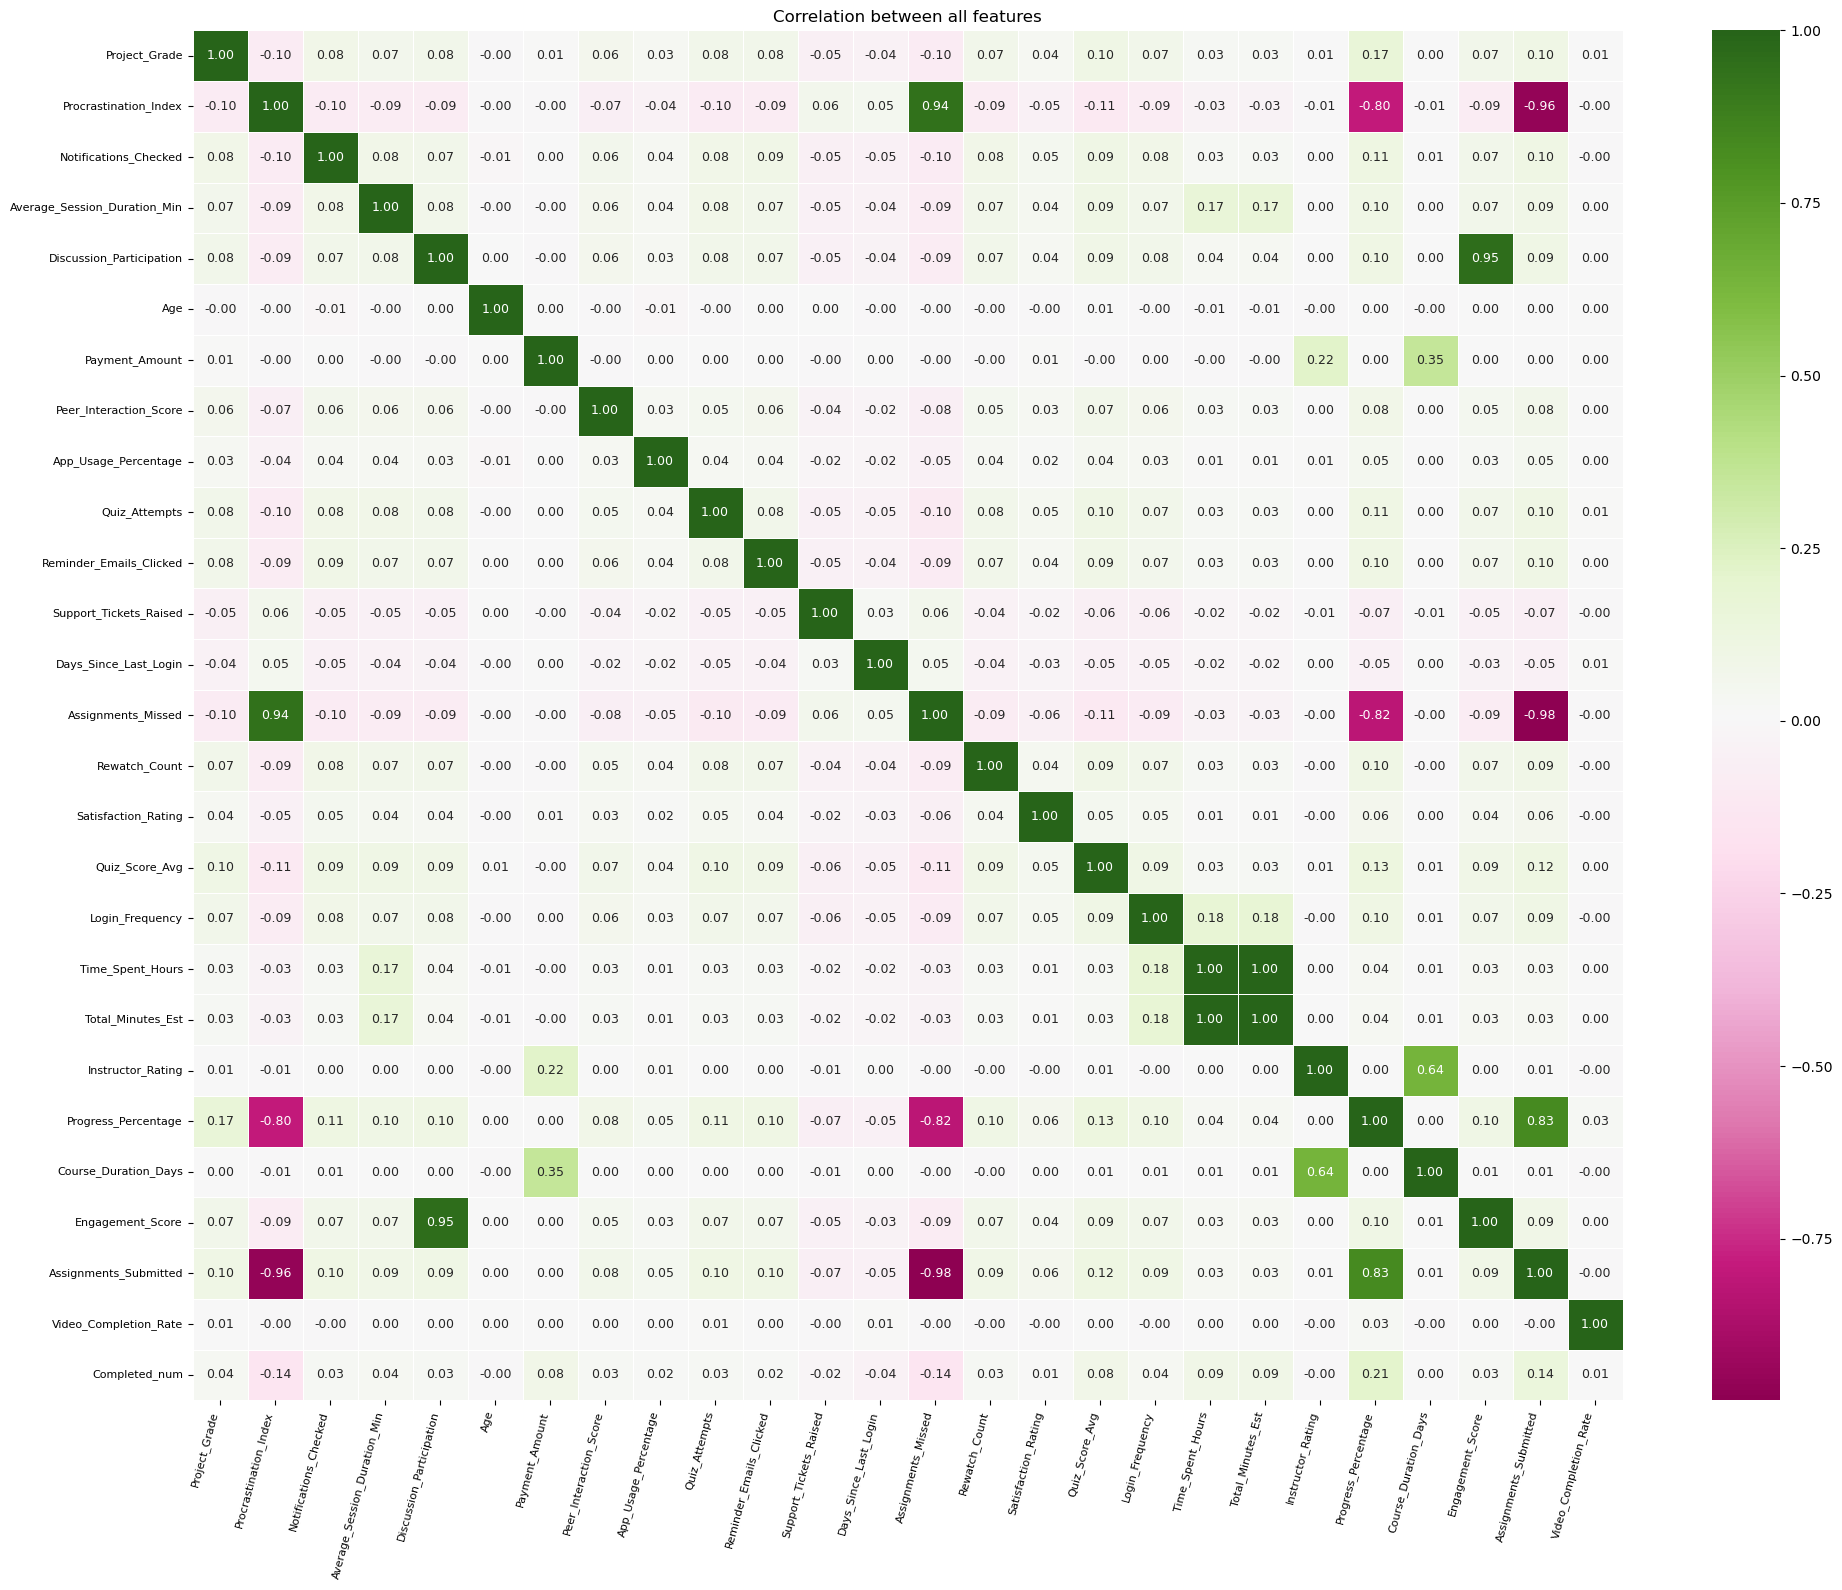

In [14]:
#doing heat map with all int, float data
plt.figure(figsize=(20, 16))
heat = sns.heatmap(pearson_corr_nona[['Project_Grade', 'Procrastination_Index', 'Notifications_Checked',
       'Average_Session_Duration_Min', 'Discussion_Participation', 'Age',
       'Payment_Amount', 'Peer_Interaction_Score', 'App_Usage_Percentage',
       'Quiz_Attempts', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised',
       'Days_Since_Last_Login', 'Assignments_Missed', 'Rewatch_Count',
       'Satisfaction_Rating', 'Quiz_Score_Avg', 'Login_Frequency',
       'Time_Spent_Hours', 'Total_Minutes_Est', 'Instructor_Rating',
       'Progress_Percentage', 'Course_Duration_Days', 'Engagement_Score',
       'Assignments_Submitted', 'Video_Completion_Rate']], annot = True, linewidths=0.5, annot_kws={"size": 9}, cmap = "PiYG", fmt=".2f")
plt.title('Correlation between all features')
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Insights from the Correlation Heatmap

The correlation heatmap highlights both strong and weak linear relationships between numerical features. 
While most variables show weak correlations, a small number of feature pairs exhibit strong relationships that provide insight into student behavior and learning outcomes.

#### Key correlations and their interpretation

- **Assignments_Missed ↔ Procrastination_Index (strong positive correlation)**  0.94
  This correlation indicates that students who exhibit higher procrastination levels tend to miss more assignments. 
  This relationship reflects a direct behavioral pattern, where delaying academic tasks increases the likelihood of missed deadlines.

- **Assignments_Submitted ↔ Procrastination_Index (strong negative correlation)**  -0.96
  Students with higher procrastination indices tend to submit fewer assignments. 
  This reinforces the impact of procrastination on academic engagement and task completion.

- **Engagement_Score ↔ Discussion_Participation (strong positive correlation)**  0.95
  Students with higher engagement scores are more likely to actively participate in discussions. 
  This suggests that discussion participation is a strong indicator of overall student engagement.

- **Assignments_Submitted ↔ Progress_Percentage (strong positive correlation)**  0.83
  Students who submit more assignments tend to have higher progress percentages, highlighting the importance of consistent task completion in course advancement.

- **Progress_Percentage ↔ Procrastination_Index (strong negative correlation)**  0.80
  Higher procrastination levels are associated with lower overall course progress, indicating that procrastination negatively affects long-term learning outcomes.

#### Other feature relationships

Most remaining feature pairs show weak or near-zero correlations. 
These variables were not emphasized because they do not exhibit strong linear relationships within this analysis.

However, these features may still be valuable as secondary or contextual indicators. 
They are more likely to support alternative analytical objectives, such as platform usage analysis, operational optimization, or user experience improvements, rather than directly influencing academic performance.

Overall, the structured analysis of correlations allows for both meaningful interpretation of student behavior and informed decisions regarding feature selection. Because of this, I decided to drop features that don't necessarily give meaningful insights.


In [96]:
# doing heat map only with important data
important_cols = [
    "Project_Grade",
    "Quiz_Score_Avg",
    "Progress_Percentage",
    "Video_Completion_Rate",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Engagement_Score",
    "Procrastination_Index",
    "Login_Frequency",
    "Discussion_Participation",
    "Rewatch_Count",
    "Total_Minutes_Est",
    "App_Usage_Percentage",
    "Satisfaction_Rating"
]
imp_data = pearson_corr_nona.loc[important_cols, important_cols].copy()

In [97]:
imp_data.columns

Index(['Project_Grade', 'Quiz_Score_Avg', 'Progress_Percentage',
       'Video_Completion_Rate', 'Assignments_Submitted', 'Assignments_Missed',
       'Engagement_Score', 'Procrastination_Index', 'Login_Frequency',
       'Discussion_Participation', 'Rewatch_Count', 'Total_Minutes_Est',
       'App_Usage_Percentage', 'Satisfaction_Rating'],
      dtype='object')

In [98]:
imp_data.shape

(14, 14)

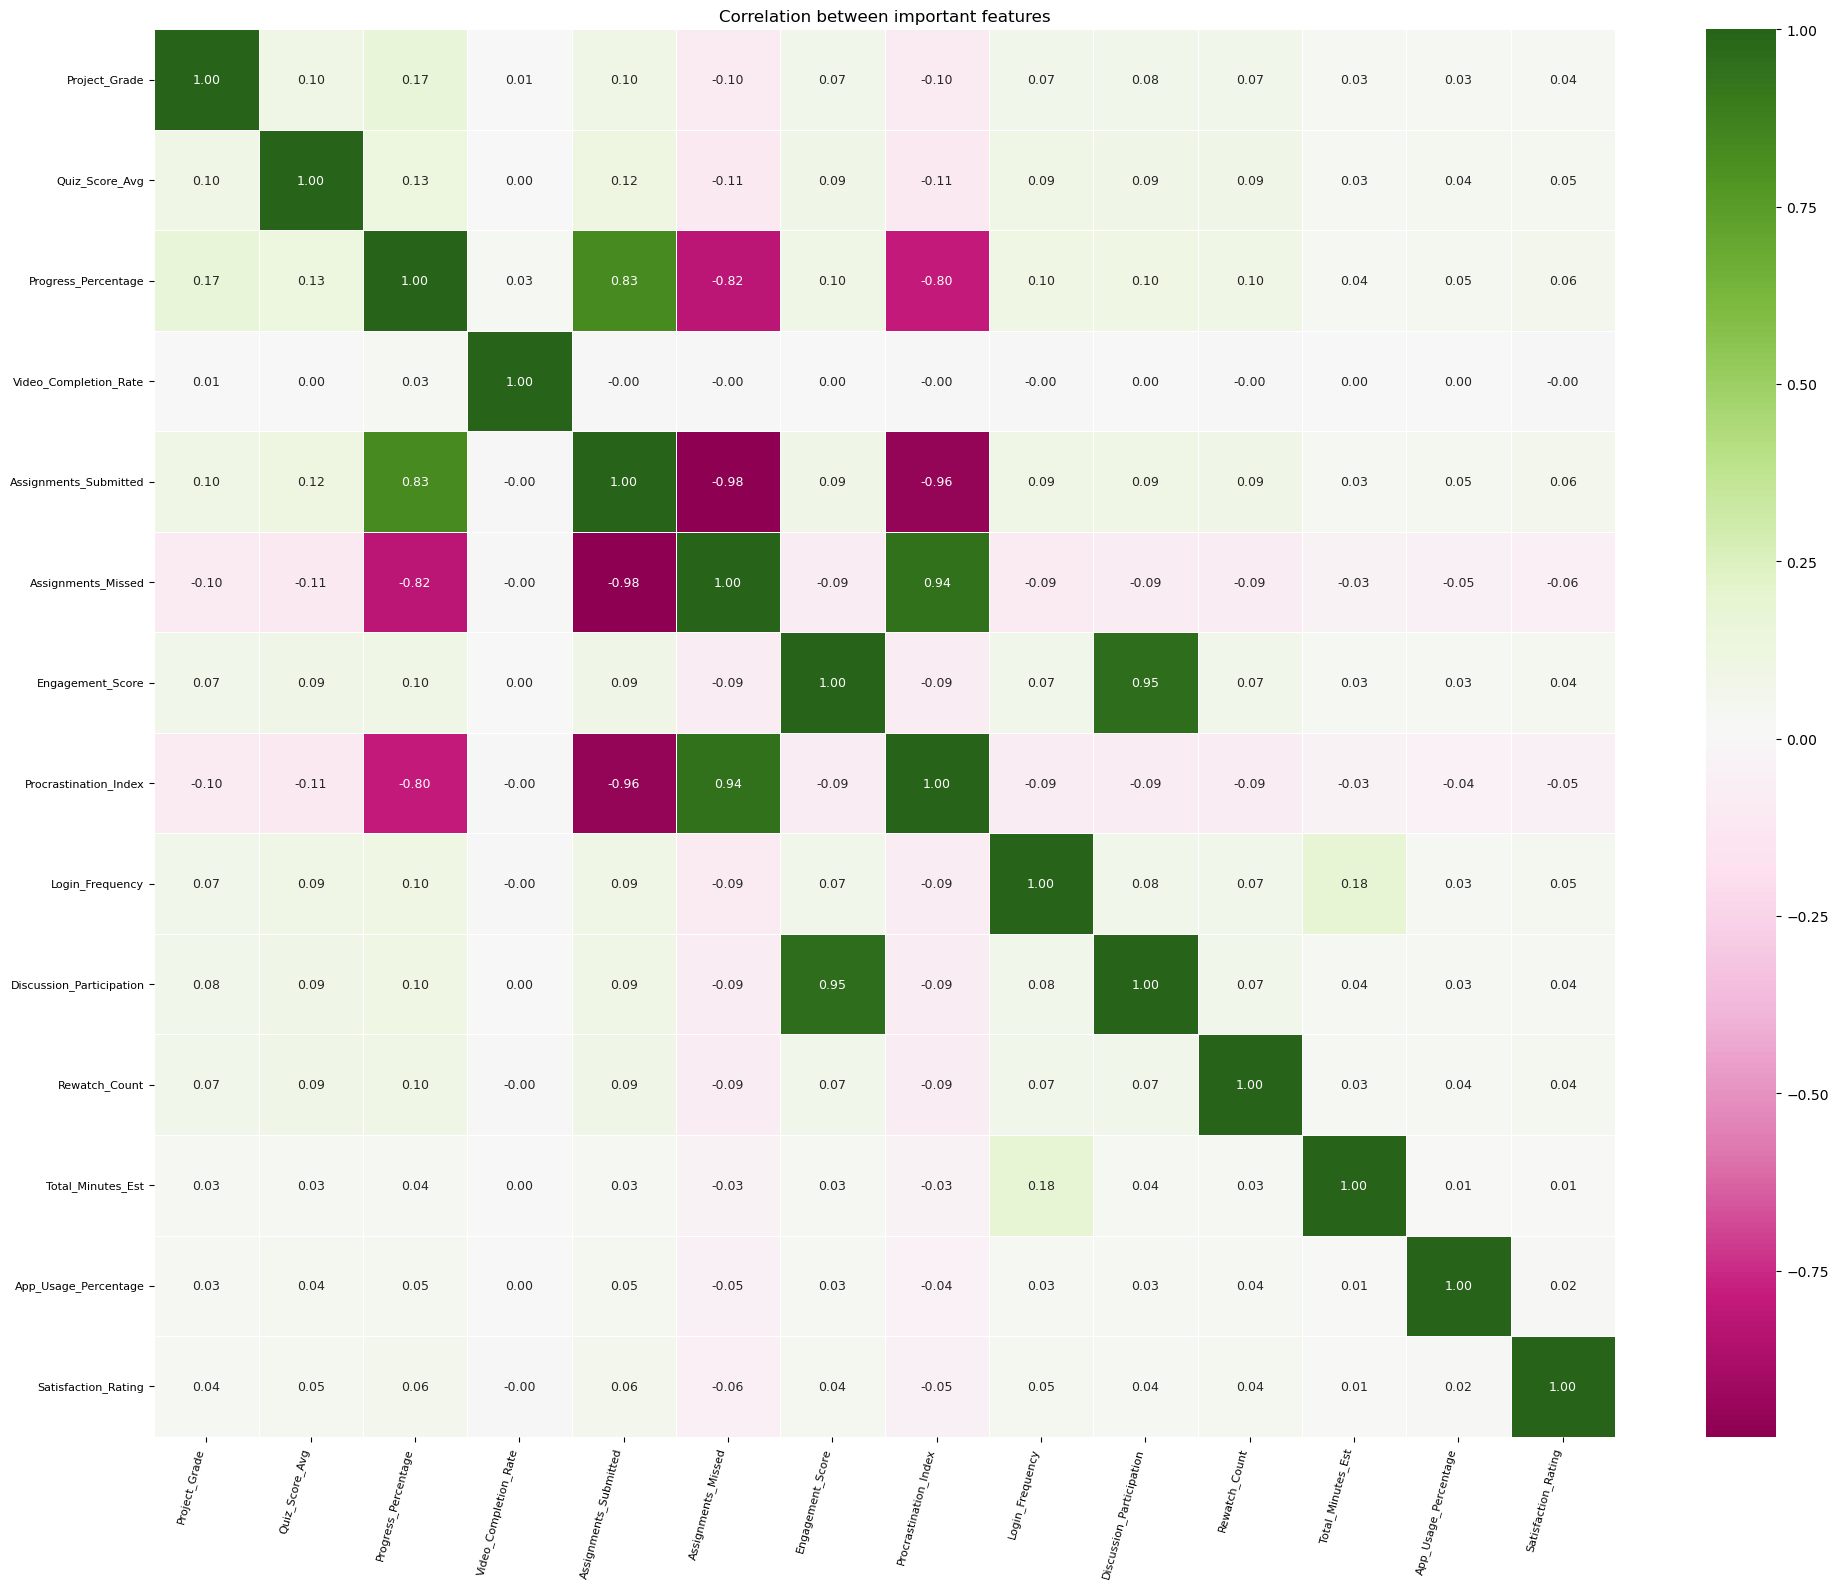

In [99]:
plt.figure(figsize=(20, 16))
heat_important = sns.heatmap(imp_data, annot = True, linewidths=0.5, annot_kws={"size": 9}, cmap = "PiYG", fmt=".2f")
plt.title('Correlation between important features')
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## II.c. Make plots to show data distributions


For this part, the analysis was divided into two main sections. 
The first section focuses on creating visualizations for numerical features only, in order to better understand their distributions and identify potential patterns or outliers. 

The second section focuses on categorical features, where appropriate plots are used to improve visualization and interpretability.


### i. Numerical Features Only

In this section, all rows containing missing values were removed to ensure that the analysis is performed only on complete observations. 
Following this cleaning step, a subset of relevant numerical features was selected for visualization.

Histograms were generated for each selected feature using a structured grid of subplots. 
This visualization approach allows the distributions of all important numerical variables to be examined simultaneously, providing insight into their shape, spread, and potential outliers, while ensuring consistency across all plots.


In [104]:
#1c plots to show data distribution
# eliminăm doar rândurile cu NA în Completed
demographic_new = demographic.dropna().copy()

# selectăm doar coloanele importante
dist_data = demographic_new[important_cols].copy()


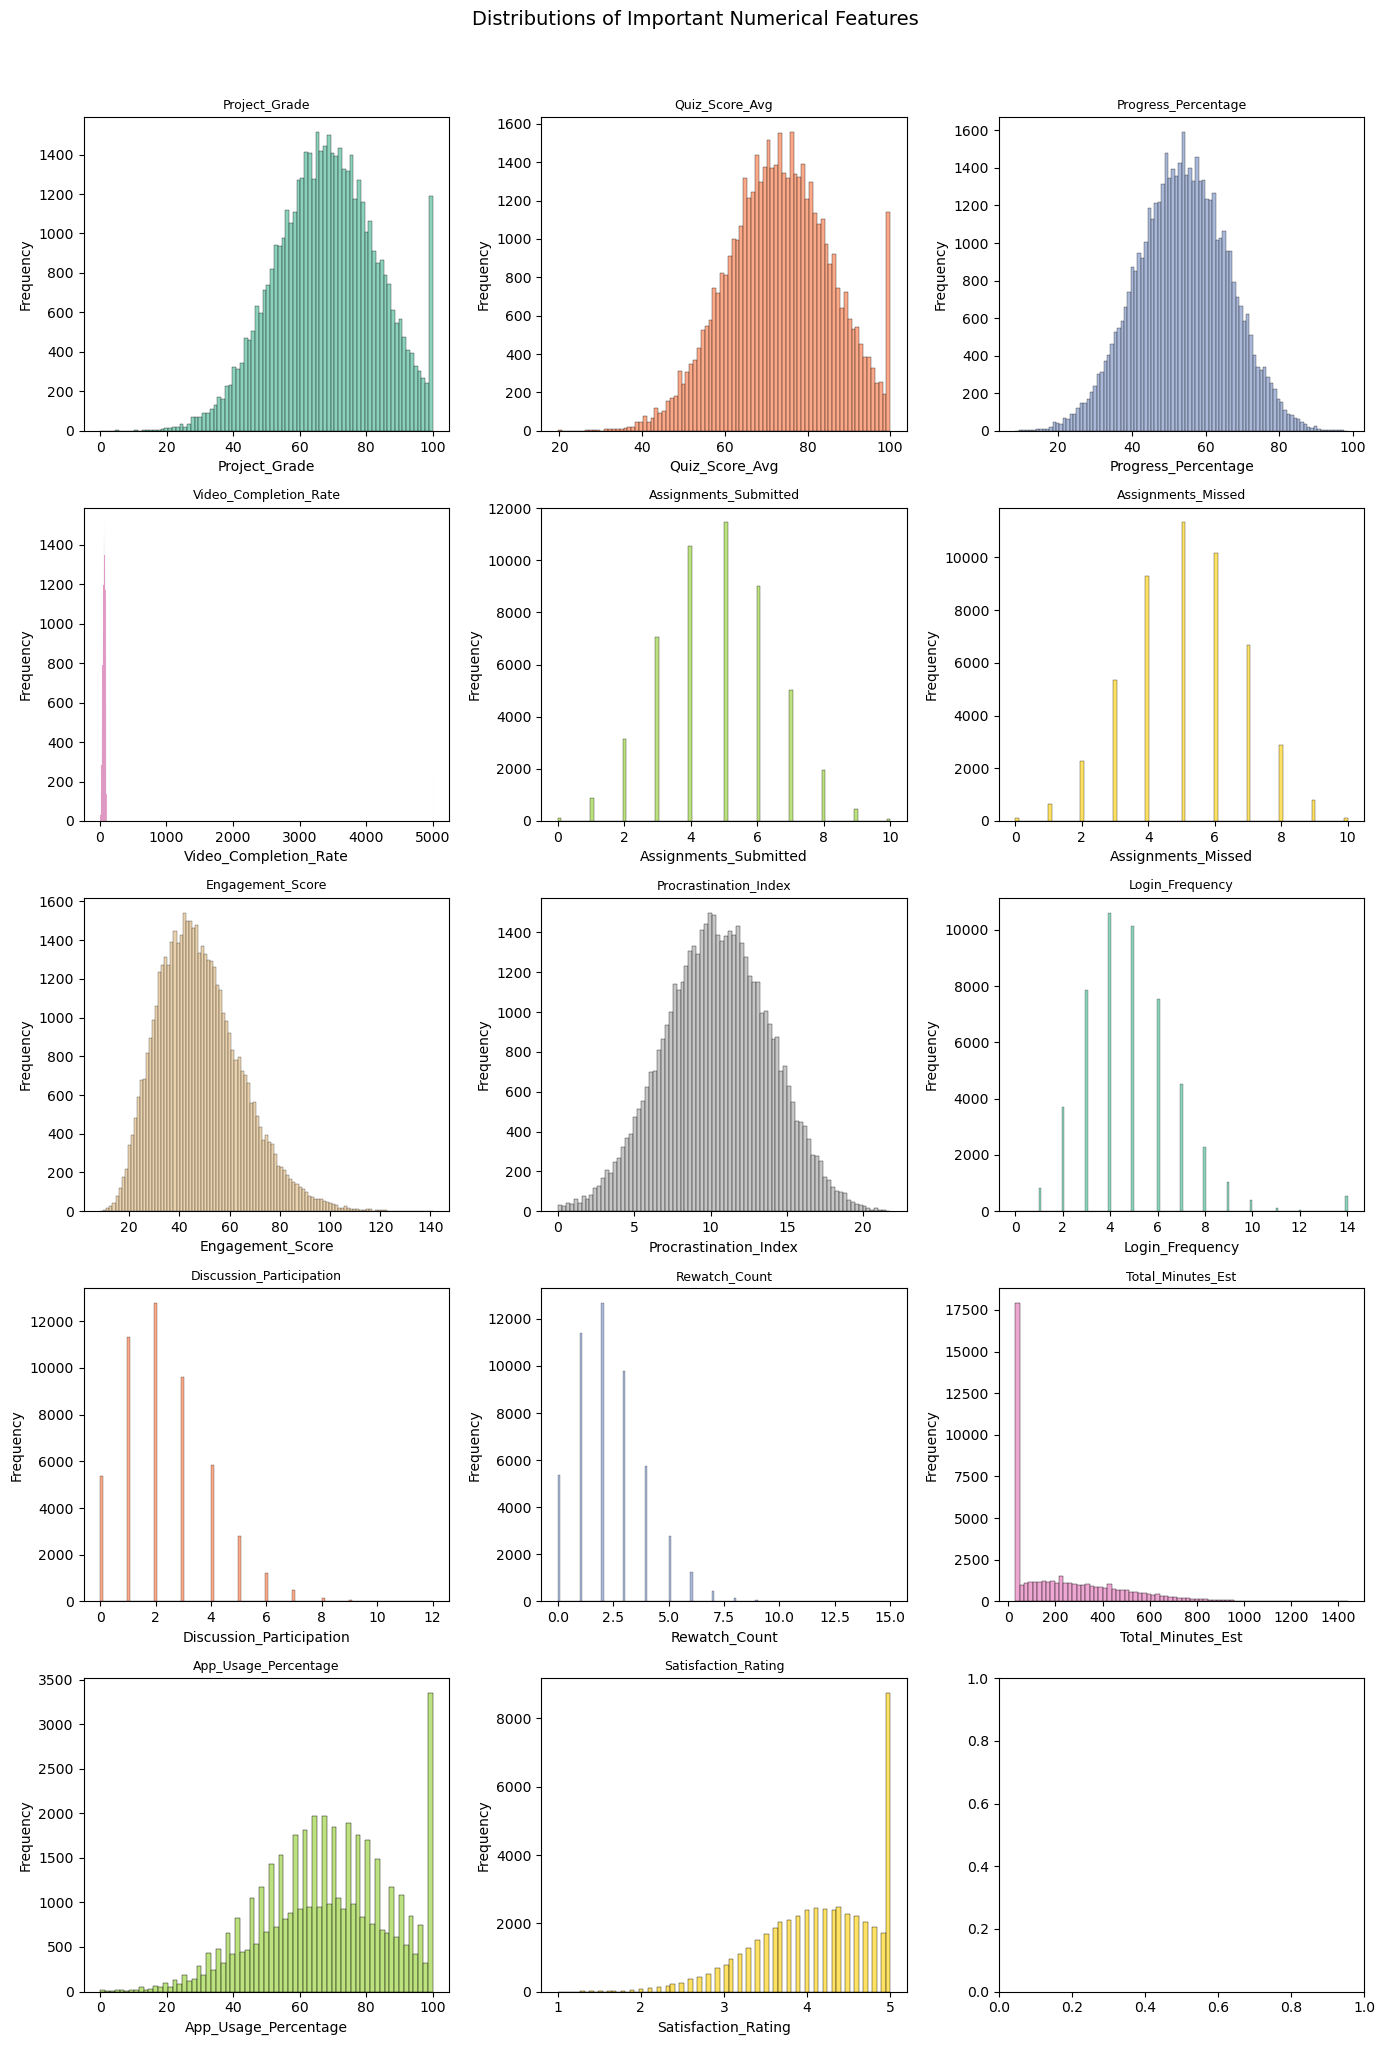

In [105]:
#create all the colors for each subplot
num_palette = sns.color_palette("Set2", len(important_cols))

#see how many rows you need in subplot grid
cols_per_row = 3 #you say how many plots per row you want
rows_needed = int(np.ceil(len(important_cols) / cols_per_row)) #calculate rows needed

#create subplot grid and prepare the axes for easy iteration
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(14, 4 * rows_needed)) #grid dimension, fig size in inches, returns fig-figure object and axes - array of subplot axes
axes = axes.flatten() if len(important_cols) > 1 else [axes] #convert

# Plot each feature
for idx, feature in enumerate(important_cols):
    sns.histplot(
        data=dist_data,
        x=feature,
        color=num_palette[idx],
        edgecolor="black",
        ax=axes[idx]
    )
    axes[idx].set_title(feature, fontsize=9)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Frequency")
    
fig.suptitle("Distributions of Important Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Key Observations from Numerical Feature Distributions

- **Academic performance variables**  
  *(Project_Grade, Quiz_Score_Avg, Progress_Percentage)*  
  These features exhibit approximately normal distributions, indicating consistent performance levels across most students.

- **Engagement-related features**  
  *(Engagement_Score, Discussion_Participation, Login_Frequency, Rewatch_Count)*  
  The distributions are generally right-skewed, suggesting that most students engage at moderate levels, while a smaller subset shows very high activity.

- **Procrastination_Index**  
  This feature follows an almost normal distribution, reflecting natural variability in procrastination behavior among students.

- **Assignment behavior**  
  *(Assignments_Submitted, Assignments_Missed)*  
  These variables display discrete distributions and align with expected behavioral patterns, supporting earlier findings from the correlation analysis.

- **Platform usage time**  
  *(Total_Minutes_Est)*  
  A strongly right-skewed distribution indicates the presence of heavy users and potential outliers.

- **User satisfaction**  
  *(Satisfaction_Rating)*  
  The distribution is skewed toward higher values, suggesting generally positive user feedback.


### Kernel Density Estimation (KDE) Plots

In addition to histograms, Kernel Density Estimation (KDE) plots were used to provide a smoother representation of the distributions of the numerical features. 
KDE plots help highlight the overall shape of each distribution without being affected by bin size or bin boundaries.

These plots confirm the patterns observed in the histograms, such as approximately normal distributions for performance-related features and right-skewed distributions for engagement and platform usage variables. 
They also make it easier to identify skewness, peaks, and potential multimodal behavior in the data.

Overall, KDE visualizations complement the histogram analysis by offering a clearer view of distribution trends and supporting the robustness of the observed patterns.


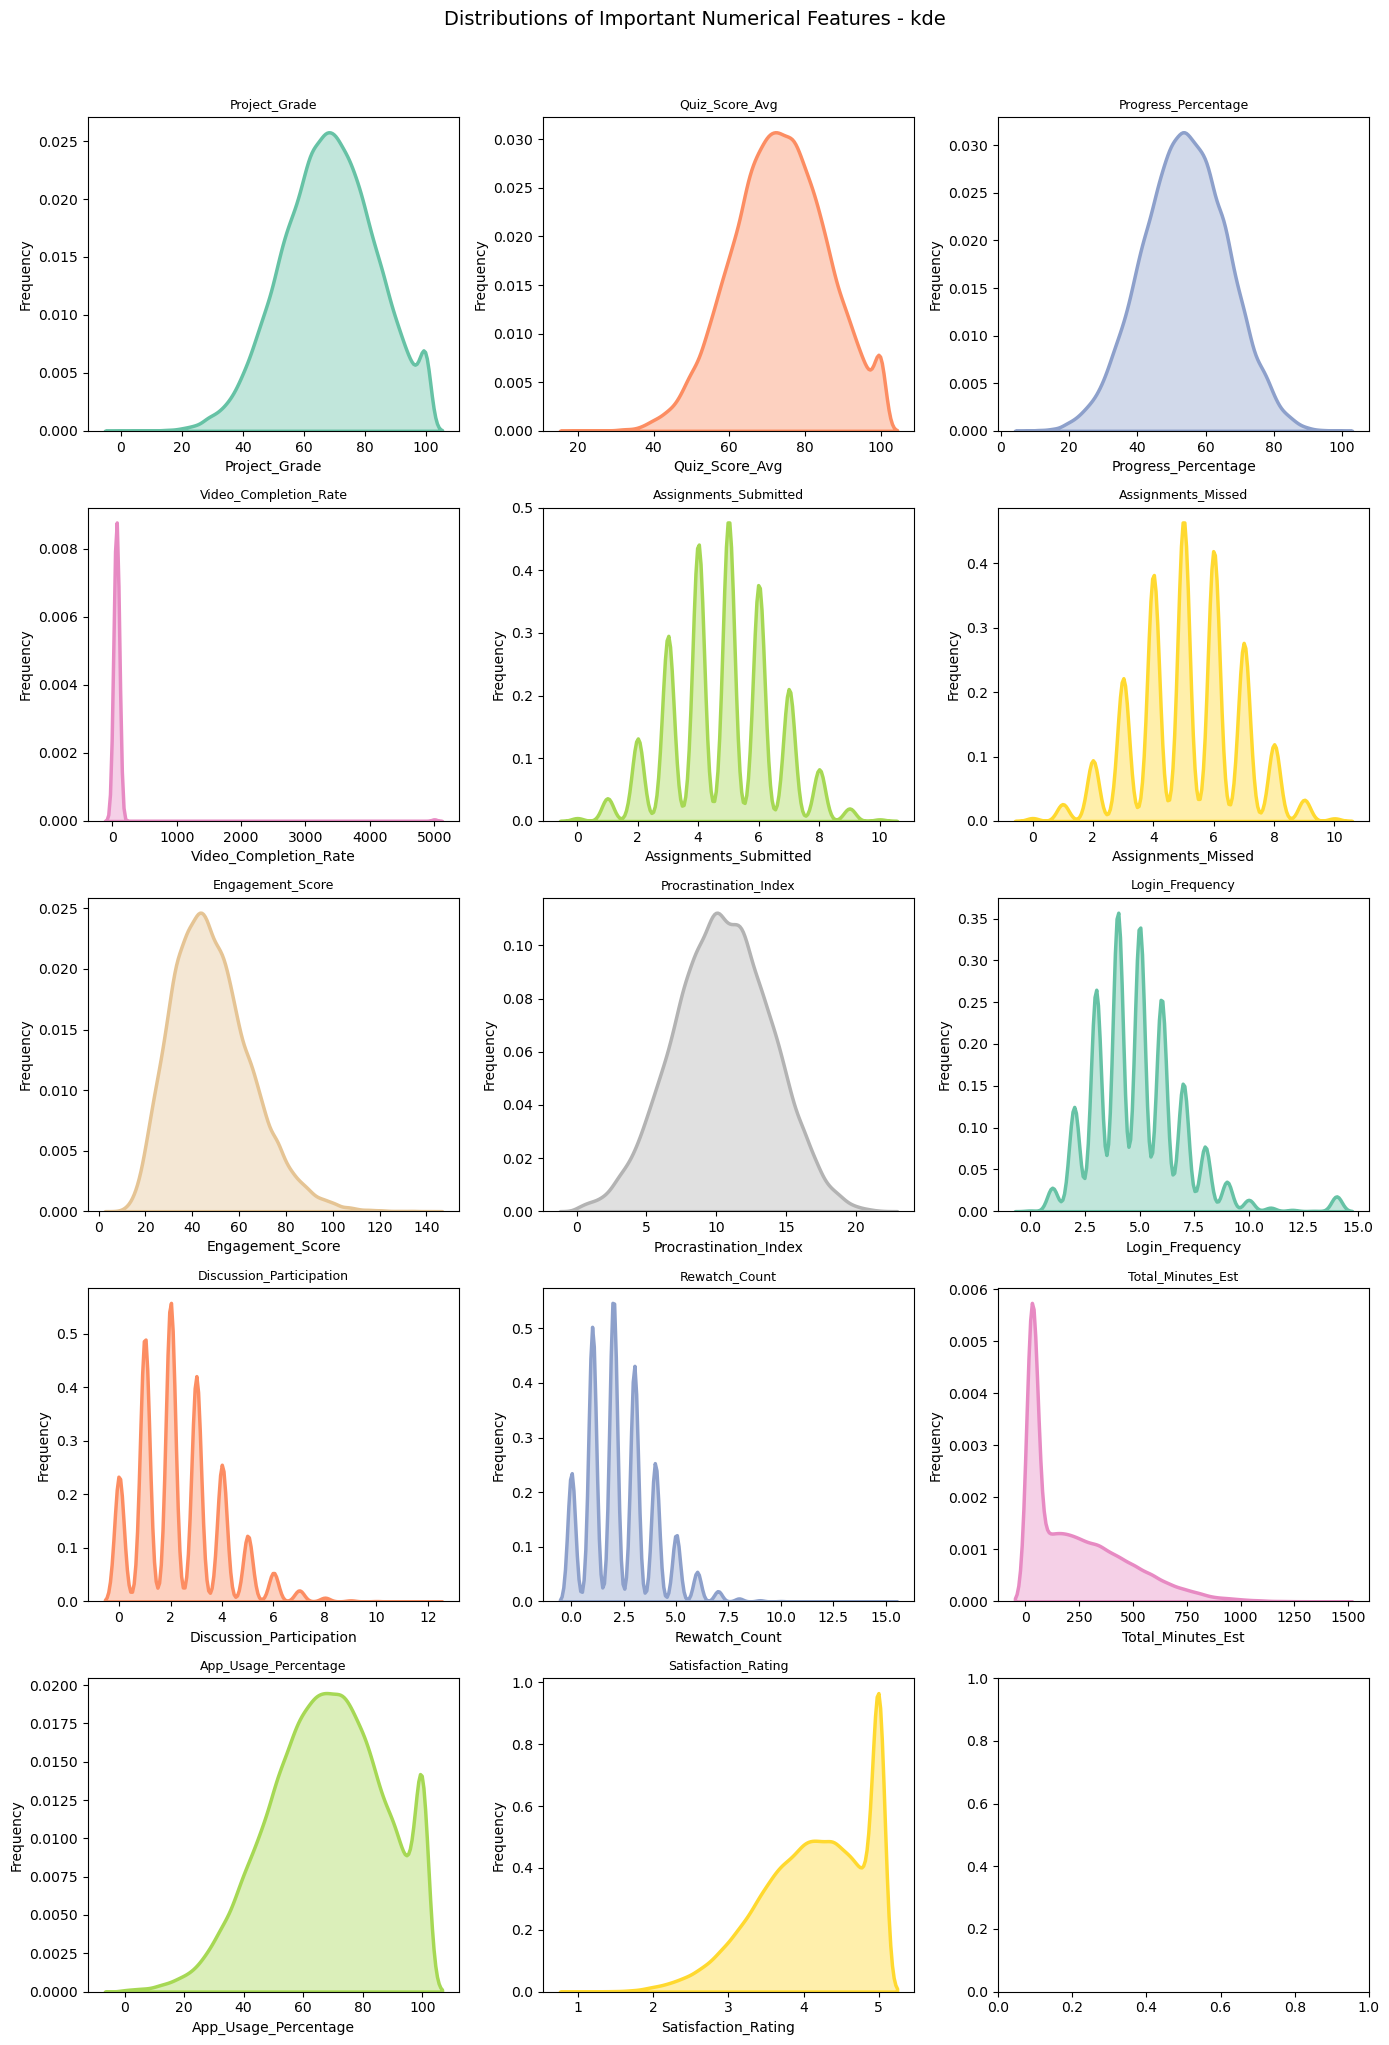

In [103]:
#also using kde - kenel density plot for more data visualisation
#create all the colors for each subplot
num_palette = sns.color_palette("Set2", len(important_cols))

#see how many rows you need in subplot grid
cols_per_row = 3 #you say how many plots per row you want
rows_needed = int(np.ceil(len(important_cols) / cols_per_row)) #calculate rows needed

#create subplot grid and prepare the axes for easy iteration
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(14, 4 * rows_needed)) #grid dimension, fig size in inches, returns fig-figure object and axes - array of subplot axes
axes = axes.flatten() if len(important_cols) > 1 else [axes] #convert
for idx, feature in enumerate(important_cols):
    sns.kdeplot(
        data=dist_data,
        x=feature,
        color=num_palette[idx],  # Use the palette you created
        linewidth=2.5,
        fill=True,
        alpha=0.4,
        ax=axes[idx]
    )
    axes[idx].set_title(feature, fontsize=9)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Frequency")
    
fig.suptitle("Distributions of Important Numerical Features - kde", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### ii. Categorical Features Only

In this section, categorical features were analyzed separately to better understand their distributions. 
All object-type columns were first identified, and features with a large number of unique values (such as IDs, names, and dates) were excluded to improve readability and interpretability.

Rows containing missing values in key categorical variables were removed to ensure consistent and clean visualizations. 
Count plots were then generated for each remaining categorical feature using a grid of subplots, allowing the frequency distribution of categories to be examined simultaneously.

This approach highlights class imbalance, dominant categories, and overall distribution patterns across categorical variables, providing complementary insights to the numerical feature analysis.


In [24]:
# Get all object/categorical columns from demographic dataframe
cat_cols = demographic.select_dtypes(include='object').columns.tolist()

# Drop NA values for specific categorical columns
demographic_cat_clean = demographic.dropna(subset=["Completed", "Device_Type", "Internet_Connection_Quality", "City"])
# Remove columns with too many unique values (like IDs, Names, Cities)
exclude_cols = ['Name', 'Student_ID', 'Course_ID', 'City', 'Enrollment_Date']

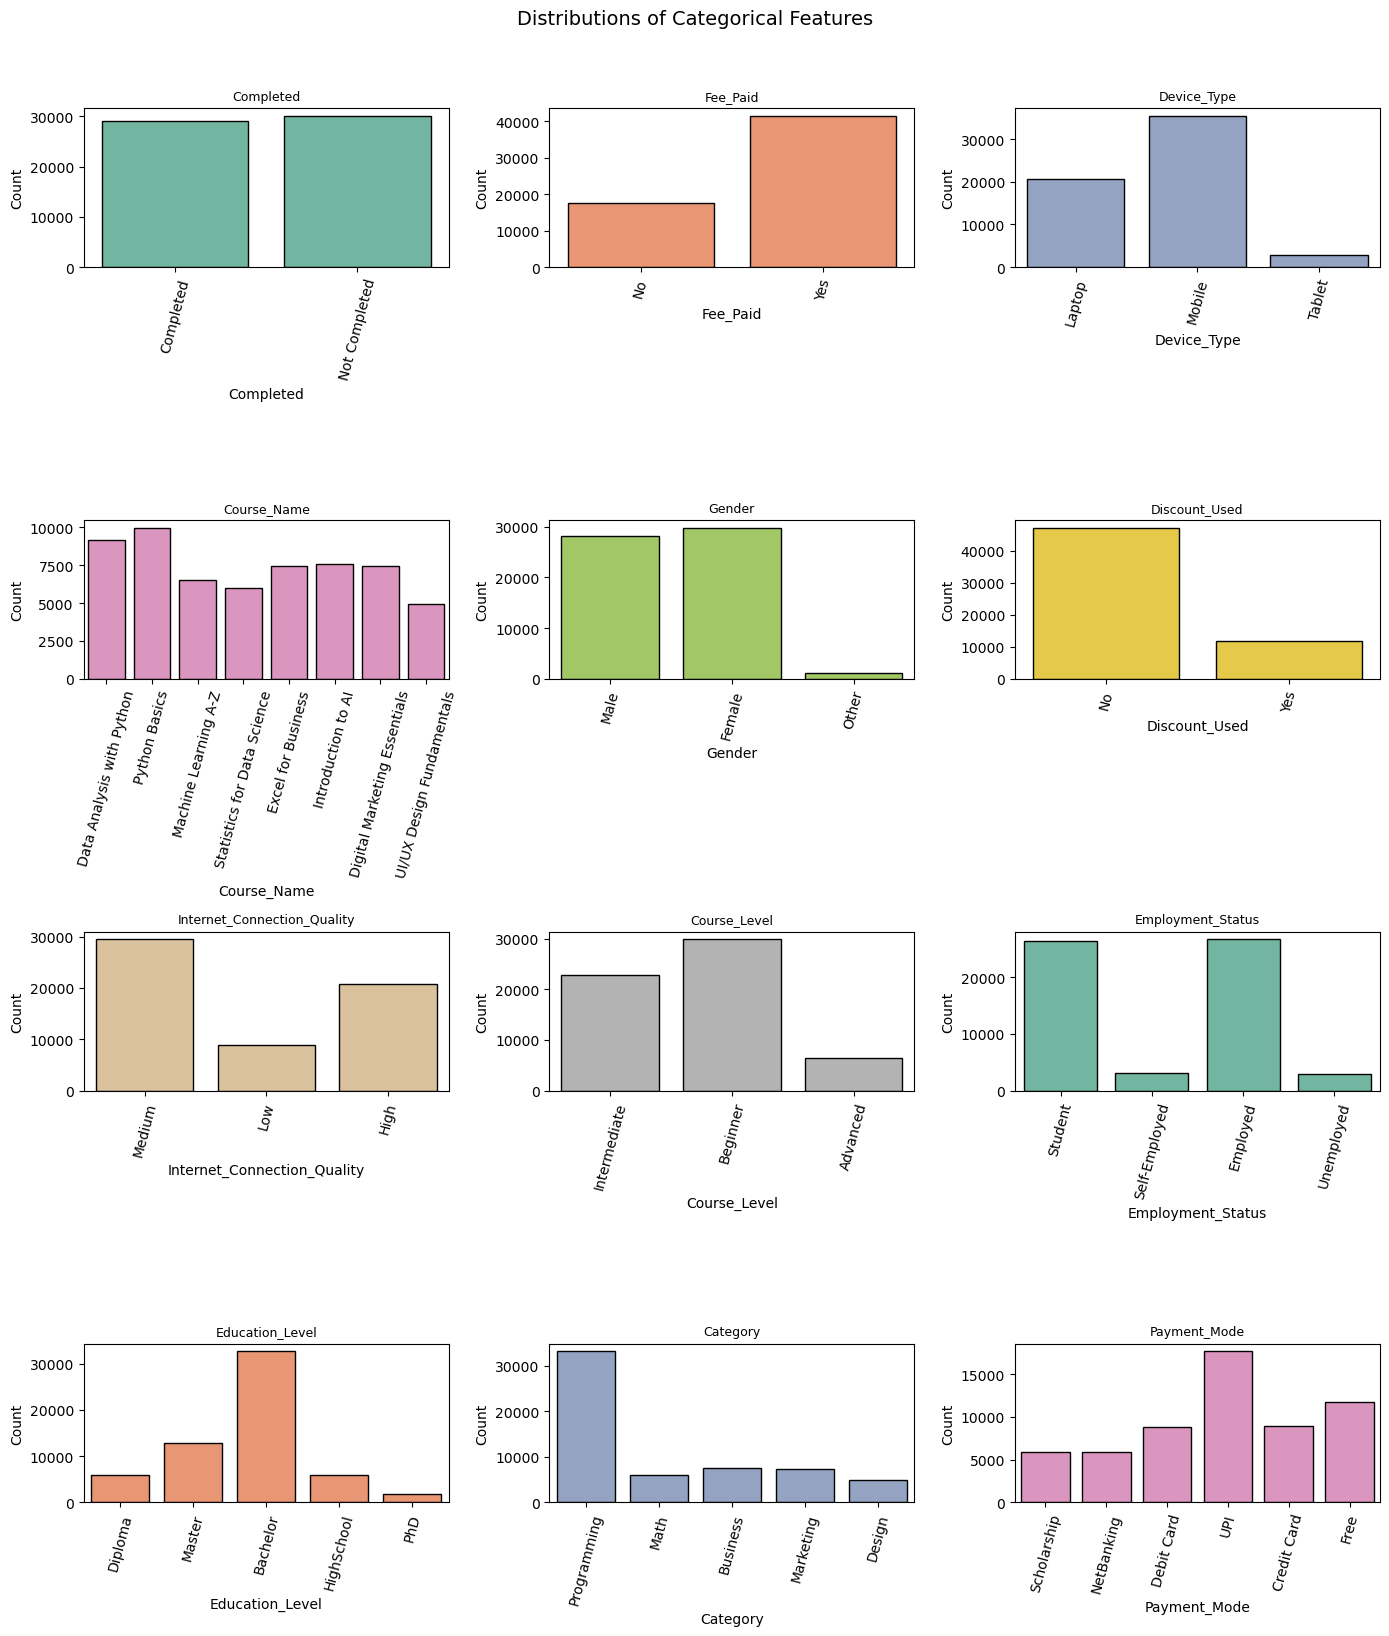

In [27]:
cat_cols = [col for col in cat_cols if col not in exclude_cols]

# Create colors for categorical plots
cat_palette = sns.color_palette("Set2", len(cat_cols))

# Calculate grid dimensions
cols_per_row = 3
rows_needed = int(np.ceil(len(cat_cols) / cols_per_row))

# Create subplots
fig, axes = plt.subplots(rows_needed, cols_per_row, figsize=(14, 4 * rows_needed))
axes = axes.flatten() if len(cat_cols) > 1 else [axes]

# Plot each categorical feature
for idx, feature in enumerate(cat_cols):
    sns.countplot(
        data=demographic_cat_clean,
        x=feature,
        color=cat_palette[idx],
        edgecolor="black",
        ax=axes[idx]
    )
    axes[idx].set_title(feature, fontsize=9)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Count")
    # Rotate x-labels if they're long
    axes[idx].tick_params(axis='x', rotation=75)

# Hide unused subplots
for idx in range(len(cat_cols), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Distributions of Categorical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### II.d. Identify Target and Feature Variables

In this step, the target variable was defined as **Completed**, representing whether a student completed the course. 
Non-predictive columns, such as identifiers and enrollment-related information, were excluded since they do not provide meaningful predictive value.

All remaining columns were treated as potential feature variables. 
The number of predictive features and their names were displayed to verify the selection process.

Finally, the distribution and data type of the target variable were inspected to better understand class balance and confirm its suitability for downstream analysis and modeling.


In [30]:
#1d target and feature var
# Define target variable
target_col = "Completed"

# Define non-predictive columns (IDs, identifiers, dates)
non_predictive_cols = [
    "Student_ID",
    "Course_ID",
    "Name",
    "Enrollment_Date"
]

# Get all predictive feature columns
predictive_cols = [
    col for col in demographic.columns
    if col not in non_predictive_cols + [target_col]
]

print(f"Target column: {target_col}")
print(f"\nNumber of features: {len(predictive_cols)}")

print("\nFeature columns:")
print(pd.DataFrame({"Feature": predictive_cols}))

# Optional: Check target distribution
print(f"\nTarget variable distribution:")
print(demographic[target_col].value_counts())
print(f"\nTarget variable type: {demographic[target_col].dtype}")

Target column: Completed

Number of features: 38

Feature columns:
                         Feature
0                  Project_Grade
1          Procrastination_Index
2          Notifications_Checked
3   Average_Session_Duration_Min
4       Discussion_Participation
5                            Age
6                 Payment_Amount
7         Peer_Interaction_Score
8           App_Usage_Percentage
9                  Quiz_Attempts
10       Reminder_Emails_Clicked
11                      Fee_Paid
12                   Device_Type
13        Support_Tickets_Raised
14         Days_Since_Last_Login
15                   Course_Name
16            Assignments_Missed
17                 Rewatch_Count
18                        Gender
19           Satisfaction_Rating
20                Quiz_Score_Avg
21                 Discount_Used
22               Login_Frequency
23              Time_Spent_Hours
24             Total_Minutes_Est
25   Internet_Connection_Quality
26                  Course_Level
27       

<a id="p1"></a>
### II.e. Highlight potential issues
Before defining potential data issues, the dataset was first inspected using `.head()`(from 2a) in order to gain an initial understanding of how the values are represented and what their expected data types should be. 
This visual inspection was then complemented by extracting structural information using `.info()`(from 2a), which provided details about how each feature was initially defined in terms of data type and missing values.

Based on this analysis, several features were identified as candidates for type conversion. 
For example, **Enrollment_Date** should be converted from an object type to a datetime format. 
Similarly, **Days_Since_Last_Login** is currently stored as a float but represents a fixed number of days and should therefore be converted to an integer. 
Additionally, **Login_Frequency** and **Total_Minutes_Est** may also be more appropriately represented as integers, as they describe count-based or time-based quantities.

Another major issue observed in the dataset is the presence of missing values. 
The highest number of missing entries appears in the **Completed** column, while other features also contain missing data to a lesser extent, as summarized in the issues table.

Finally, inconsistencies in value formatting were identified in certain features. 
For instance, **Login_Frequency** contains highly precise decimal values (e.g., *14.026825256728207* for student *Rahul Kumar*), which is not meaningful for a frequency-based metric and further supports the need for type standardization.



In [43]:
def detect_type_change(col_name, dtype):
    if "Date" in col_name:
        return "Yes → datetime"
    if col_name in ["Days_Since_Last_Login"]:
        return "Yes → int"
    if col_name in ["Login_Frequency", "Total_Minutes_Est"]:
        return "Maybe → int"
    return "No"

issues_table["Type Change Needed"] = [
    detect_type_change(col, dtype)
    for col, dtype in zip(issues_table["Column"], issues_table["Type"])
]

issues_table = issues_table[
    ["Column", "Type", "Type Change Needed", "Missing Values"]
]
issues_table


,Column,Type,Type Change Needed,Missing Values
Name,Name,object,No,0
Project_Grade,Project_Grade,float64,No,0
Enrollment_Date,Enrollment_Date,object,Yes → datetime,0
Procrastination_Index,Procrastination_Index,float64,No,0
Completed,Completed,object,No,25000
Notifications_Checked,Notifications_Checked,int64,No,0
Average_Session_Duration_Min,Average_Session_Duration_Min,float64,No,0
Discussion_Participation,Discussion_Participation,int64,No,0
Age,Age,int64,No,0
Payment_Amount,Payment_Amount,int64,No,0


# III. Data preprocessing
## In this section, the dataset is prepared for further analysis and modeling by addressing data quality issues identified during exploratory data analysis, including handling missing values, correcting data types, and ensuring consistency across features.


### III.a. Identify outliers

In this step, a subset of the dataset containing only predictive features and the target variable was created to ensure consistency during preprocessing. 
All numerical features were then selected, as outlier detection is most relevant for continuous or count-based variables.

An outlier is a data point that deviates significantly from the majority of observations in a dataset. 
Outliers are typically values that fall far above or below the normal range of a feature and may indicate unusual behavior, measurement errors, or rare but valid cases.

In boxplots, outliers are visualized as points lying outside the whiskers, which usually represent values beyond 1.5 times the interquartile range (IQR). 
Identifying outliers is important because they can disproportionately influence statistical analyses and machine learning models.

The use of boxplots provides a simple and effective method for detecting extreme values that may require further investigation or treatment during preprocessing.


In [110]:
#2 Data processing
#2a identify outliers, target_col=completed from 1d
df_preprocessed = demographic[predictive_cols + [target_col]].copy()
# Get numerical columns
numerical_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()


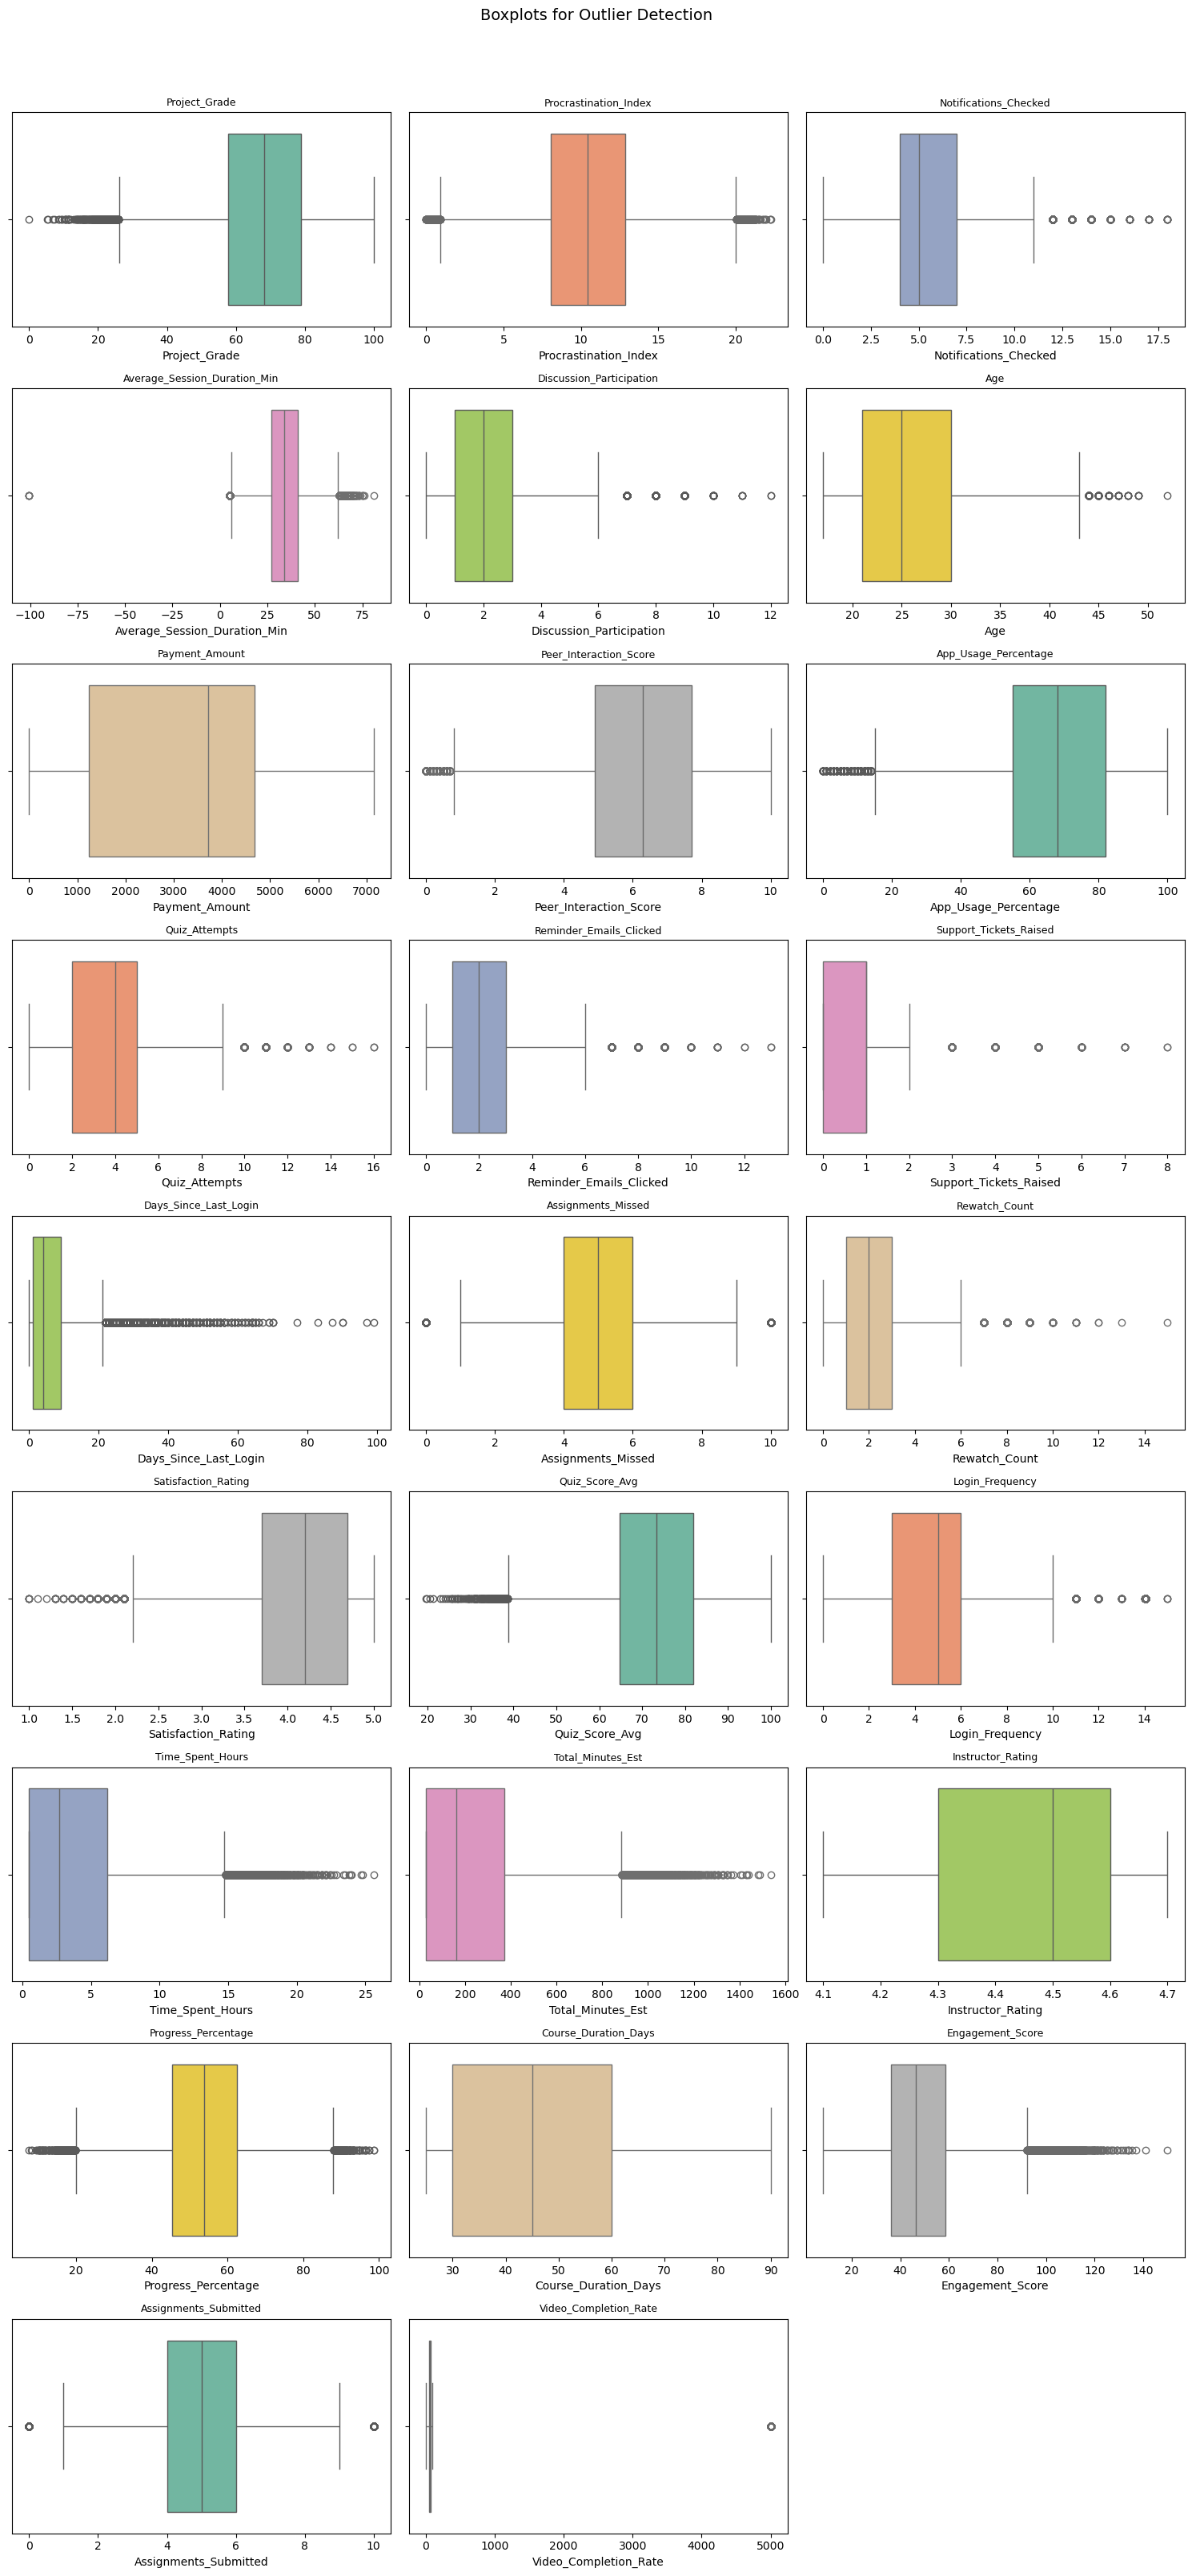

In [112]:
# Create colors for numerical plots
num_palette = sns.color_palette("Set2", len(numerical_cols))

plots_per_row = 3
rows_needed = int(np.ceil(len(numerical_cols) / plots_per_row))

plt.figure(figsize=(5 * plots_per_row, 3.5 * rows_needed))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows_needed, plots_per_row, i + 1)
    sns.boxplot(x=col, data=df_preprocessed, color=num_palette[i])
    plt.title(col, fontsize=9)

plt.suptitle("Boxplots for Outlier Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


The boxplots show that most numerical features fall within plausible ranges; however, several variables contain clear outliers. 
Performance-related features such as **Project_Grade**, **Quiz_Score_Avg**, and **Progress_Percentage** display relatively compact interquartile ranges, suggesting stable academic performance for the majority of students.

In contrast, several engagement and platform usage variables, including **Days_Since_Last_Login**, **Engagement_Score**, **Rewatch_Count**, **Quiz_Attempts**, **Time_Spent_Hours**, and **Total_Minutes_Est**, are strongly right-skewed. 
These distributions indicate that while most students exhibit moderate levels of activity, a small subset shows unusually high values, representing highly engaged or atypical user behavior.

Additionally, some features reveal potential data quality issues. 
For example, **Average_Session_Duration_Min** contains a small number of negative values, and **Video_Completion_Rate** includes extremely large values that are likely erroneous rather than behavior-driven.


### Distribution Analysis Using Histograms and KDE

In this step, histograms combined with Kernel Density Estimation (KDE) were generated for all numerical features. 
This visualization approach provides both a discrete and a smooth representation of each feature’s distribution, allowing for a clearer assessment of central tendency, spread, skewness, and potential outliers.

The inclusion of KDE curves helps confirm patterns observed in previous distribution and boxplot analyses, particularly the presence of right-skewed variables and heavy tails. 
These insights support informed decisions regarding scaling, transformation, or outlier handling in subsequent preprocessing steps.


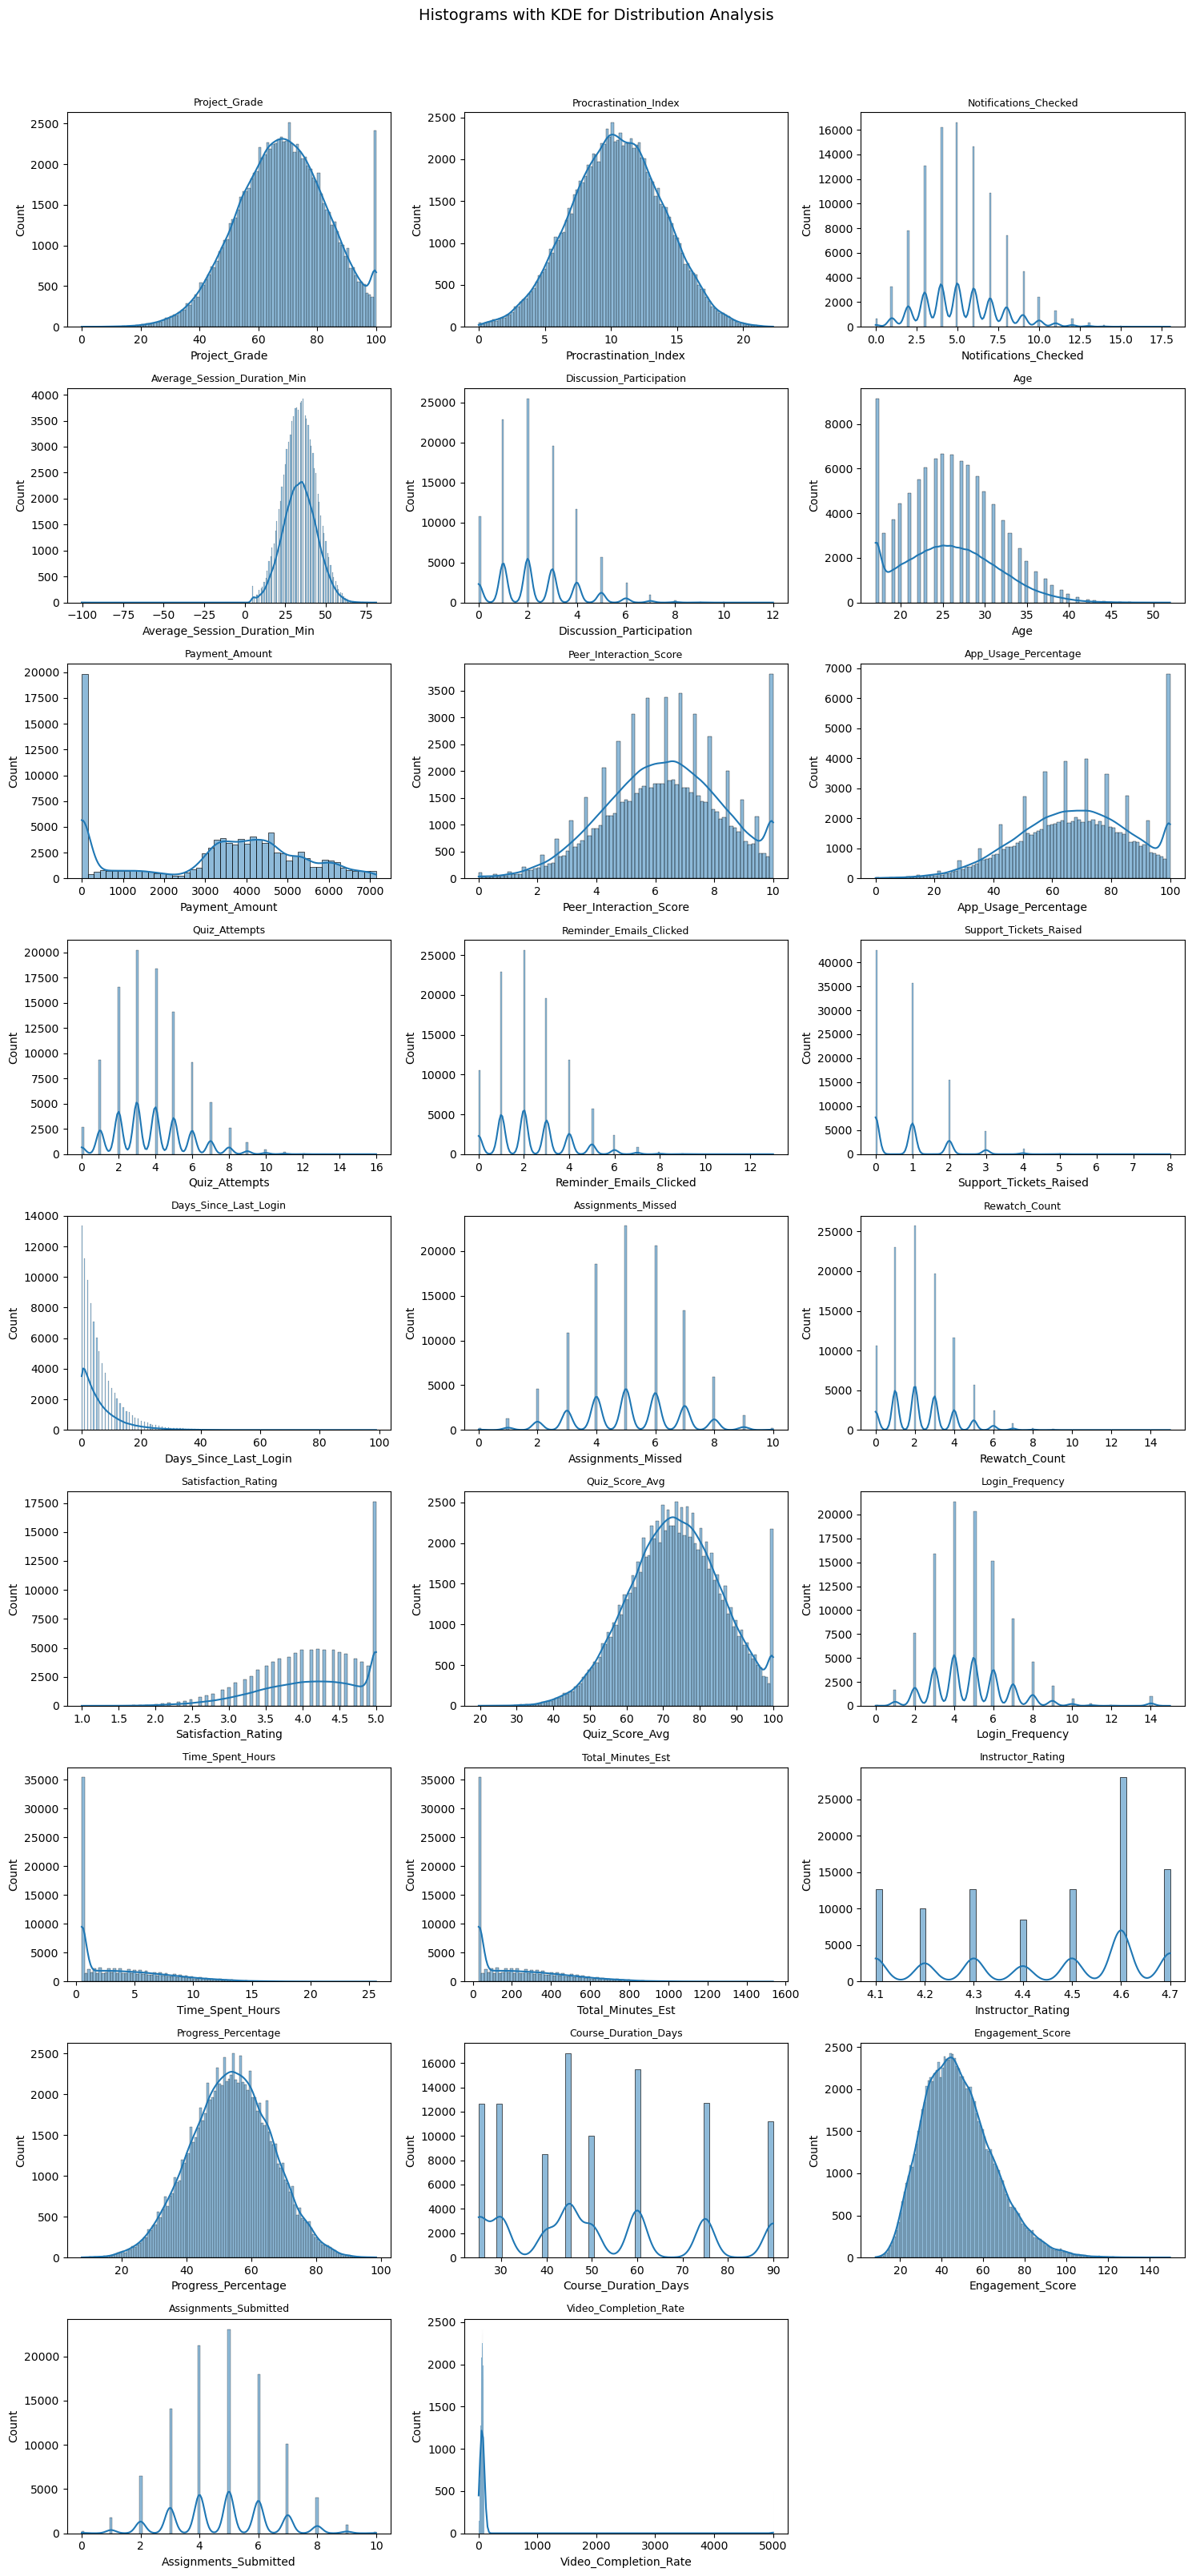

In [109]:
plt.figure(figsize=(5 * plots_per_row, 3.5 * rows_needed))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows_needed, plots_per_row, i + 1)
    sns.histplot(x=col, data=df_preprocessed, kde=True)
    plt.title(col, fontsize=9)

plt.suptitle("Histograms with KDE for Distribution Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### III.b. Deal with missing values

Several columns in the dataset contain missing values, with the highest number of missing entries observed in the **Completed** column, followed by other features with smaller amounts of missing data. 
These missing values can interfere with downstream analysis and model training, as most machine learning algorithms require complete input data.

To address this issue, missing values need to be handled appropriately to ensure that each observation is fully defined. 
One common approach is to replace missing values with suitable substitutes based on the characteristics of each feature. 
This process is known as **imputation**, and it allows the dataset to remain usable while minimizing information loss.

In the following steps, different imputation strategies will be applied to replace missing values and prepare the data for modeling.


In [114]:
#2b deal with missing values
# first we show where missing values exist
def missing_values_table(df):
    """Display missing values count and percentage"""
    missing = pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
    })
    missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    return missing

# Check missing values in preprocessed data
print("\nMissing values before imputation:")
missing_before = missing_values_table(df_preprocessed)
print(missing_before)




Missing values before imputation:
                             Missing_Count  Missing_Percentage
Completed                            25000              25.000
Peer_Interaction_Score                9315               9.315
Device_Type                           8661               8.661
Internet_Connection_Quality           8534               8.534
Days_Since_Last_Login                 7472               7.472
City                                  5443               5.443


### Handling Missing Values (Imputation Strategy)

In this step, missing values were handled using feature-type–specific imputation strategies. 
Numerical features were imputed using the **median**, while categorical features were imputed using the **mode (most frequent value)**. 
This approach helps preserve the distribution of numerical variables and maintains valid category labels for categorical features.

Before imputing the predictors, the target variable (**Completed**) was checked separately for missing values. 
If missing values were present, they were imputed using the mode for categorical targets or the median for numerical targets, ensuring that the target variable remains complete for model training.

After handling the target variable, the dataset was split into feature variables (`X`) and the target variable (`y`). 
The number of missing values in each feature was recorded prior to imputation to allow comparison and validation of the preprocessing step.

Finally, predictive features were separated into numerical and categorical subsets. 
This separation enables the application of appropriate imputation techniques for each data type and prepares the dataset for further preprocessing and modeling.


In [120]:
# First, handle missing values in target column if any
if df_preprocessed[target_col].isna().sum() > 0:
    print(f"\n Warning: Target column '{target_col}' has missing values!")
    n_missing_target = df_preprocessed[target_col].isna().sum()
    
    if df_preprocessed[target_col].dtype == 'object':
        mode_val = df_preprocessed[target_col].mode()[0]
        df_preprocessed[target_col] = df_preprocessed[target_col].fillna(mode_val)
    else:
        median_val = df_preprocessed[target_col].median()
        df_preprocessed[target_col] = df_preprocessed[target_col].fillna(median_val)

# Separate features and target
X = df_preprocessed.drop(columns=[target_col])
y = df_preprocessed[target_col]

# Record missing values before imputation
missing_before = X.isna().sum()

# Separate numerical and categorical columns
numeric_predictive_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_predictive_cols = X.select_dtypes(include='object').columns.tolist()

### Feature Imputation

In this step, missing values in the predictive features were imputed using strategies appropriate to each data type. 
For numerical features, missing values were replaced with the **median**, which is robust to outliers and helps preserve the overall distribution of the data. 
For categorical features, missing values were replaced with the **mode**, ensuring that valid and meaningful category labels are maintained.

During the imputation process, information about each imputed feature—including the imputation strategy and the value used—was recorded for transparency and reproducibility. 
After completing the imputation, the number of missing values was recalculated to verify that all predictive features are free of missing data.

This approach ensures that the dataset is complete and suitable for subsequent modeling steps.


In [121]:
impute_info = []

# Impute numeric features with median
for col in numeric_predictive_cols:
    n_missing = X[col].isna().sum()
    if n_missing > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        impute_info.append({
            "Feature": col,
            "Imputation_strategy": "Median",
            "Imputation_value": median_val
        })

# Impute categorical features with mode
for col in categorical_predictive_cols:
    n_missing = X[col].isna().sum()
    if n_missing > 0:
        mode_val = X[col].mode().iloc[0]
        X[col] = X[col].fillna(mode_val)
        impute_info.append({
            "Feature": col,
            "Imputation_strategy": "Mode",
            "Imputation_value": mode_val
        })

# Record missing values after imputation
missing_after = X.isna().sum()


In [122]:
# Update df_preprocessed with imputed X and y
df_preprocessed = X.copy()
df_preprocessed[target_col] = y

In [67]:
df_preprocessed.head(12)

,Project_Grade,Procrastination_Index,Notifications_Checked,Average_Session_Duration_Min,Discussion_Participation,Age,Payment_Amount,Peer_Interaction_Score,App_Usage_Percentage,Quiz_Attempts,Reminder_Emails_Clicked,Fee_Paid,Device_Type,Support_Tickets_Raised,Days_Since_Last_Login,Course_Name,Assignments_Missed,Rewatch_Count,Gender,Satisfaction_Rating,Quiz_Score_Avg,Discount_Used,Login_Frequency,Time_Spent_Hours,Total_Minutes_Est,Internet_Connection_Quality,Course_Level,Employment_Status,Instructor_Rating,Progress_Percentage,Education_Level,Course_Duration_Days,Engagement_Score,Assignments_Submitted,City,Video_Completion_Rate,Category,Payment_Mode,Completed
0,71.2,2.44,6.0,30.0,2,19.0,1740,4.3,49.0,5.0,3,No,Laptop,2.5,1.0,Data Analysis with Python,1,0,Male,3.5,80.9,No,3.0,0.5,30.0,Medium,Intermediate,Student,4.7,70.8,Diploma,60,49.17,8,Indore,55.0,Programming,Scholarship,Completed
1,42.5,12.64,5.0,37.0,2,17.0,6147,7.8,86.0,3.0,0,Yes,Mobile,0.0,3.0,Machine Learning A-Z,6,2,Female,4.5,78.4,No,4.0,0.9,54.0,Low,Advanced,Student,4.6,55.6,Bachelor,90,45.76,4,Delhi,84.1,Programming,Credit Card,Not Completed
2,87.9,3.46,5.0,9.0,3,34.0,4280,6.7,85.0,3.0,1,Yes,Mobile,0.0,19.0,Python Basics,2,2,Female,5.0,100.0,No,5.0,0.5,30.0,Medium,Beginner,Student,4.6,78.8,Master,45,53.15,8,Chennai,75.6,Programming,NetBanking,Completed
3,51.4,20.00,9.0,27.0,1,29.0,3812,6.4,42.0,4.0,2,Yes,Mobile,2.5,4.0,UI/UX Design Fundamentals,9,4,Female,3.8,59.1,No,2.0,7.4,444.0,High,Beginner,Employed,4.4,24.7,Diploma,40,37.01,1,Surat,63.3,Design,UPI,Completed
4,93.0,9.28,7.0,36.0,1,19.0,5486,7.5,91.0,8.0,3,Yes,Laptop,0.0,4.0,Machine Learning A-Z,5,4,Female,4.0,84.8,Yes,2.0,0.5,30.0,Medium,Advanced,Self-Employed,4.6,64.9,Master,90,41.02,5,Lucknow,86.4,Programming,Debit Card,Completed
5,65.6,6.19,9.0,30.0,1,21.0,4526,6.2,74.0,4.0,5,Yes,Mobile,2.0,4.0,Data Analysis with Python,3,5,Female,4.5,99.6,No,7.0,11.8,708.0,Medium,Intermediate,Student,4.7,75.3,Bachelor,60,32.12,7,Jaipur,85.9,Programming,UPI,Completed
6,80.4,16.14,6.0,43.0,5,22.0,5682,7.2,83.0,5.0,2,Yes,Mobile,0.0,0.0,Introduction to AI,7,1,Male,4.8,74.4,No,5.0,0.5,30.0,Medium,Intermediate,Employed,4.5,55.1,Diploma,75,79.46,3,Chennai,94.5,Programming,UPI,Completed
7,72.9,5.37,6.0,12.0,1,23.0,4590,5.4,68.0,3.0,0,Yes,Mobile,0.0,1.0,Python Basics,3,3,Male,5.0,76.3,No,8.0,0.5,30.0,Low,Beginner,Employed,4.6,73.4,Master,45,38.86,7,Hyderabad,79.2,Programming,NetBanking,Completed
8,69.4,0.90,6.0,20.0,2,17.0,5055,6.3,78.0,6.0,4,Yes,Tablet,2.0,2.0,Introduction to AI,1,2,Male,4.7,76.3,Yes,7.0,0.9,54.0,Medium,Intermediate,Student,4.5,87.9,Bachelor,75,44.28,9,Nagpur,82.3,Programming,Credit Card,Not Completed
9,54.1,11.97,2.0,30.0,2,32.0,2951,6.4,48.0,3.0,1,Yes,Laptop,2.0,0.0,Digital Marketing Essentials,7,0,Male,4.4,55.8,Yes,7.0,3.3,198.0,Medium,Beginner,Student,4.3,42.9,Bachelor,30,38.90,3,Kolkata,63.4,Marketing,UPI,Completed


### Updating the Preprocessed Dataset

After imputing missing values in both the feature set and the target variable, the cleaned features (`X`) and target (`y`) were recombined into a single DataFrame. 
This updated dataset represents the fully preprocessed version of the data, with no missing values remaining.

The first few rows of the dataset were displayed to verify that the imputation was applied correctly and that the data structure remains consistent.


### III.c. Deal with categorical data

Machine learning models typically require numerical inputs. 
Therefore, categorical features are transformed into a numerical representation using **one-hot encoding**, which converts each category into a separate binary indicator.
This process allows categorical information to be incorporated into models without introducing artificial ordinal relationships between categories. 

In [124]:
#2c deal with categorical data
cols_to_drop = ["Name", "Student_ID", "Course_Name", "Course_ID", "Enrollment_Date",
                "Fee_Paid", "Payment_Mode", "City", "Total_Minutes_Est"]
cols_to_drop = [c for c in cols_to_drop if c in X.columns]

if len(cols_to_drop) > 0:
    X = X.drop(columns=cols_to_drop)

In [125]:
categorical_predictive_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_predictive_cols = X.select_dtypes(include=["number"]).columns.tolist()

if len(categorical_predictive_cols) > 0:
    cat_df = pd.DataFrame({"Categorical_predictive_feature": categorical_predictive_cols})

In [127]:
#shape_before = X.shape
X_encoded = pd.get_dummies(X, columns=categorical_predictive_cols, drop_first=True)
#shape_after = X_encoded.shape
'''
shape_df = pd.DataFrame([
    {"Stage": "Before encoding", "n_rows": shape_before[0], "n_features": shape_before[1]},
    {"Stage": "After encoding",  "n_rows": shape_after[0],  "n_features": shape_after[1]},
])
print("Shape of X before and after one-hot encoding:")
print(shape_df)
print()

'''

'\nshape_df = pd.DataFrame([\n    {"Stage": "Before encoding", "n_rows": shape_before[0], "n_features": shape_before[1]},\n    {"Stage": "After encoding",  "n_rows": shape_after[0],  "n_features": shape_after[1]},\n])\nprint("Shape of X before and after one-hot encoding:")\nprint(shape_df)\nprint()\n\n'

In [128]:
# Map target variable to binary
y_encoded = y.map({
    "Completed": 1,
    "Not Completed": 0
})

y_counts = y_encoded.value_counts(dropna=False).rename_axis("Y_value").reset_index(name="Count")
y_counts["Proportion"] = (y_counts["Count"] / len(y_encoded)).round(4)

# Update variables for next steps
X = X_encoded
y = y_encoded

In this step, non-predictive and high-cardinality features (such as identifiers, names, dates, and location-related variables) were removed from the feature set, as they do not provide meaningful predictive value and could introduce noise into the model.

After dropping these columns, the remaining features were separated into numerical and categorical predictors. 
Categorical features were then transformed using **one-hot encoding**, converting each category into a binary indicator while avoiding redundancy by dropping the first category level.
One-hot encoding is a technique used to convert categorical variables into a numerical format that can be used by machine learning models. 
Each unique category in a feature is represented as a separate binary (0 or 1) column, where a value of 1 indicates the presence of that category and 0 indicates its absence.

Additionally, the target variable (**Completed**) was mapped to a binary numerical format, where `1` represents *Completed* and `0` represents *Not Completed*. 
The distribution of the encoded target variable was inspected to assess class balance.

Finally, the feature matrix (`X`) and target vector (`y`) were updated to reflect the fully encoded dataset, preparing them for subsequent modeling steps.

### III.d. Standardize or normalize numerical features as needed

Numerical features often have different scales and ranges, which can negatively impact the performance of certain machine learning models. 
In this step, numerical variables are standardized or normalized as needed to ensure that all features contribute equally during model training.


In [136]:
#2d standardize or normalize numerical features as needed
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns, index=X_encoded.index)

In [133]:
desc_scaled = X_scaled.describe().loc[["mean", "std"]].round(3)
print("First 5 rows of scaled features:")
print(X_scaled.head())
print()


First 5 rows of scaled features:
   Project_Grade  Procrastination_Index  Notifications_Checked  \
0       0.196609              -2.308949               0.319758   
1      -1.677743               0.630507              -0.096653   
2       1.287260              -2.015004              -0.096653   
3      -1.096498               2.751527               1.568991   
4       1.620333              -0.337784               0.736169   

   Average_Session_Duration_Min  Discussion_Participation       Age  \
0                     -0.372747                 -0.206924 -1.194884   
1                      0.301299                 -0.206924 -1.551056   
2                     -2.394885                  0.421470  1.476406   
3                     -0.661624                 -0.835318  0.585976   
4                      0.205007                 -0.835318 -1.194884   

   Payment_Amount  Peer_Interaction_Score  App_Usage_Percentage  \
0       -0.726080               -1.058463             -0.985435   
1        

In [135]:
# Encode target if it's categorical
Y_binary = y.map({"Completed": 1, "Not Completed": 0}) if y.dtype == "O" else y

# Separate labeled and unlabeled data
labeled_mask = Y_binary.notna().values
unlabeled_mask = Y_binary.isna().values

Y_labeled = Y_binary[labeled_mask]
Y_unlabeled = Y_binary[unlabeled_mask]

# Show target distribution for labeled data
if len(Y_labeled) > 0:
    y_dist = Y_labeled.value_counts().sort_index()

In this step, numerical features were standardized using **StandardScaler**, which transforms each feature to have a mean of 0 and a standard deviation of 1. 
Standardization is particularly important for models that are sensitive to feature scale, as it ensures that all variables contribute equally during training.

After scaling, the standardized features were converted back into a DataFrame to preserve feature names and indexing. 
Descriptive statistics were then examined to confirm that the scaling was applied correctly, with means close to zero and standard deviations close to one.

Additionally, the target variable was encoded into a binary format when necessary. 
The dataset was then separated into labeled and unlabeled observations based on the availability of the target variable. 
This separation ensures that only valid labeled data is used for supervised learning, while unlabeled observations can be handled separately if needed.

Finally, the distribution of the labeled target variable was inspected to assess class balance prior to model training.

### III.e. Use principal component analysis(PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform a high-dimensional dataset into a smaller set of uncorrelated components while preserving as much variance as possible. 
By projecting the data onto a new feature space, PCA helps reduce redundancy, mitigate multicollinearity, and improve computational efficiency.


In [137]:
#2e use principal component analysis
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Total features: {X_scaled.shape[1]}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Dimensionality reduction: {X_scaled.shape[1]} → {n_components_95} features")
print(f"Reduction percentage: {((X_scaled.shape[1] - n_components_95) / X_scaled.shape[1] * 100):.1f}%\n")


Total features: 45
Components for 95% variance: 36
Dimensionality reduction: 45 → 36 features
Reduction percentage: 20.0%



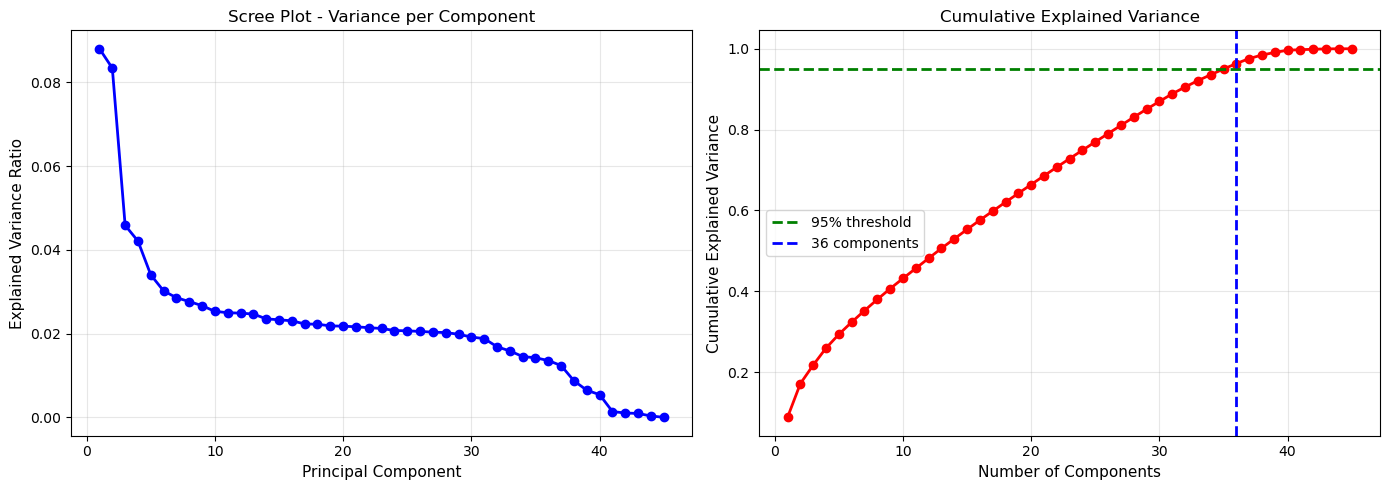

In [139]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot - individual variance per component
n_show = min(50, len(pca_full.explained_variance_ratio_))
ax1.plot(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show], 'bo-', linewidth=2)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11)
ax1.set_title('Scree Plot - Variance per Component', fontsize=12)
ax1.grid(True, alpha=0.3)

# Cumulative variance plot
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2)
ax2.axhline(y=0.95, color='g', linestyle='--', linewidth=2, label='95% threshold')
ax2.axvline(x=n_components_95, color='b', linestyle='--', linewidth=2, 
            label=f'{n_components_95} components')
ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax2.set_title('Cumulative Explained Variance', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


PCA was first fitted using all available components in order to assess how much variance each principal component explains.

The cumulative explained variance was then calculated to determine the minimum number of components required to retain at least 95% of the original data variance. 
This threshold was used to balance dimensionality reduction with information preservation.

Two visualizations were generated to support this analysis: a scree plot showing the variance explained by each individual component, and a cumulative variance plot illustrating how the explained variance increases as more components are included. 

The scree plot shows that the first few principal components explain a relatively large proportion of the total variance, followed by a gradual decline in explained variance across subsequent components. 
This indicates that much of the information in the dataset is captured by the leading components, while later components contribute increasingly smaller amounts of variance.

The cumulative explained variance plot demonstrates that approximately **36 principal components** are required to retain **95% of the total variance** in the data. 
Beyond this point, adding additional components yields only marginal gains in explained variance.

Overall, these results indicate that the original feature space can be substantially reduced while preserving most of the informational content. 
Applying PCA with 36 components allows for effective dimensionality reduction, reduces redundancy among features, and can improve model efficiency without significant loss of information.


In [156]:
pca = PCA(n_components=n_components_95)
X_pca_array = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca_array, 
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=X_scaled.index
)

# Show variance explained by top components
top_components = min(10, n_components_95)
variance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(top_components)],
    'Variance_Explained': pca.explained_variance_ratio_[:top_components],
    'Cumulative_Variance': cumulative_variance[:top_components]
}).round(4)

print(f"Top {top_components} Principal Components:")
print(variance_df)
print()

Top 10 Principal Components:
  Component  Variance_Explained  Cumulative_Variance
0       PC1              0.0880               0.0880
1       PC2              0.0834               0.1714
2       PC3              0.0458               0.2172
3       PC4              0.0421               0.2593
4       PC5              0.0340               0.2933
5       PC6              0.0302               0.3235
6       PC7              0.0286               0.3520
7       PC8              0.0276               0.3797
8       PC9              0.0267               0.4063
9      PC10              0.0253               0.4316



In [140]:
print("First 5 rows of PCA-transformed data:")
print(X_pca.head())
print()

First 5 rows of PCA-transformed data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.527692  1.758915 -1.713488 -0.143887  0.935928  1.184962 -0.448056   
1 -0.853805  2.240438 -0.515096 -0.905013  1.201269 -2.051483  1.148488   
2  3.986541 -0.078188 -0.530089 -1.469411  0.465249  1.027109  0.885046   
3 -5.203499 -1.690984  0.123906 -0.726233 -0.405982 -0.070667  0.634831   
4  1.534138  2.011592  0.187704 -0.928385 -2.083171  0.319463 -1.914878   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  2.341102 -0.605280 -0.734406  0.562449  0.395170  1.177550  2.022893   
1  0.188154 -0.392215  1.276669 -0.569864  0.097214 -0.355081  0.221244   
2  0.609799  2.012006  1.294816 -0.411515 -0.332872 -0.936222  0.722086   
3 -0.017916 -0.986232  0.039134 -1.683021  3.317133  0.852392  1.349106   
4 -2.727764  0.754470  1.873885 -0.538000 -0.173987 -2.185785  1.861530   

       PC15      PC16      PC17      PC18      PC19      PC2

### Applying PCA Transformation

The standardized feature set was transformed into a lower-dimensional representation consisting of principal components.

The transformed data was stored in a new DataFrame with clearly labeled principal components. 
To improve interpretability, the variance explained by the top principal components was examined, along with their cumulative contribution to the total variance.

Finally, the first few rows of the PCA-transformed dataset were displayed to verify the transformation and ensure that the reduced feature set is ready for subsequent modeling steps.

The displayed table shows the first rows of the dataset after applying Principal Component Analysis (PCA). 
Each row now represents an observation described by principal components (PC1, PC2, ..., PCn) instead of the original features.

The principal component values are continuous and centered around zero, with both positive and negative values. 
This indicates that the data has been successfully standardized and projected onto a new orthogonal feature space.

Each principal component captures a different direction of variance in the data, and the components are uncorrelated with one another. 

### IV. Handling Imbalance

Imbalanced datasets can lead to biased models that favor the majority class.

**SMOTE (Synthetic Minority Over-sampling Technique)** generates new synthetic samples for the minority class by interpolating between existing observations. 
This approach increases class balance without discarding information from the majority class.

**Random Under-sampling** reduces the number of observations in the majority class by randomly removing samples. 
While this method is computationally efficient, it may result in information loss if important majority-class samples are removed.


Before applying resampling techniques, only observations with known target labels were selected to ensure a valid analysis. 
The distribution of the target variable was then computed to quantify the degree of class imbalance.

By identifying the majority and minority classes and calculating the imbalance ratio, this step provides a clear measure of how skewed the dataset is. 
Understanding the imbalance ratio is essential for selecting appropriate strategies, such as oversampling or undersampling, and for interpreting model performance in later stages.

In [144]:
# Use only labeled data
X_labeled = X[y.notna()]
y_labeled = y[y.notna()]

original_distribution = Counter(y_labeled)

In [145]:
# Calculate imbalance ratio
minority_class = min(original_distribution, key=original_distribution.get)
majority_class = max(original_distribution, key=original_distribution.get)
imbalance_ratio = original_distribution[majority_class] / original_distribution[minority_class]

print(f"\nMajority class ({majority_class}): {original_distribution[majority_class]} samples")
print(f"Minority class ({minority_class}): {original_distribution[minority_class]} samples")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")


Majority class (0): 63193 samples
Minority class (1): 36807 samples
Imbalance ratio: 1.72:1


### Method 1: SMOTE (Synthetic Minority Over-sampling Technique)

To address class imbalance, SMOTE was applied to the labeled dataset by increasing the number of minority-class samples. 
Unlike simple duplication, SMOTE creates new synthetic observations by interpolating between existing minority-class instances, resulting in more diverse and informative samples.

Following the resampling process, the class distribution was re-evaluated to confirm that both classes are now balanced. 
In addition, the total number of samples and the number of newly generated observations were reported to clearly illustrate the impact of the oversampling strategy.


In [151]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_labeled, y_labeled)

smote_distribution = Counter(y_smote)
print(f"Class distribution after SMOTE: {dict(smote_distribution)}")
print(f"Total samples after SMOTE: {len(y_smote)}")
print(f"Samples added: {len(y_smote) - len(y_labeled)}")


Class distribution after SMOTE: {1: 63193, 0: 63193}
Total samples after SMOTE: 126386
Samples added: 26386


### Method 2: Random Under-Sampling

As an alternative approach to handling class imbalance, Random Under-Sampling was applied to the labeled dataset. 
This method balances the classes by randomly removing samples from the majority class until both classes contain an equal number of observations.

After applying under-sampling, the class distribution was examined to verify that the dataset is balanced. 
The total number of remaining samples and the number of removed observations were reported to quantify the reduction in dataset size.

While this approach is computationally efficient, it may result in the loss of potentially informative data from the majority class. 
Therefore, its impact on model performance must be carefully evaluated and compared with oversampling techniques such as SMOTE.


In [152]:
# Apply Random Under-sampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_labeled, y_labeled)

rus_distribution = Counter(y_rus)
print(f"Class distribution after Under-sampling: {dict(rus_distribution)}")
print(f"Total samples after Under-sampling: {len(y_rus)}")
print(f"Samples removed: {len(y_labeled) - len(y_rus)}")

Class distribution after Under-sampling: {0: 36807, 1: 36807}
Total samples after Under-sampling: 73614
Samples removed: 26386


### Comparison of Class Balancing Methods

To evaluate the impact of the applied resampling techniques, a comparison table was created summarizing the class distributions before and after balancing. 
The table reports the number of samples in each class, the total dataset size, and the resulting balance ratio for the original dataset, SMOTE, and Random Under-Sampling.

This comparison highlights how SMOTE increases the dataset size by generating synthetic minority-class samples, while Random Under-Sampling achieves balance by reducing the majority class. 
By examining these differences, it becomes easier to assess the trade-offs between preserving data quantity and achieving class balance, supporting an informed choice of resampling strategy for model training.

In practice, SMOTE is often favored when the dataset is moderately sized and contains complex decision boundaries, while Random Under-Sampling can be useful as a baseline or in scenarios where speed and simplicity are prioritized. 

In [153]:
comparison_df = pd.DataFrame({
    'Method': ['Original', 'SMOTE', 'Under-sampling'],
    'Class_0': [original_distribution[0], smote_distribution[0], rus_distribution[0]],
    'Class_1': [original_distribution[1], smote_distribution[1], rus_distribution[1]],
    'Total_Samples': [len(y_labeled), len(y_smote), len(y_rus)],
    'Balance_Ratio': [
        f"{original_distribution[majority_class]/original_distribution[minority_class]:.2f}:1",
        f"{smote_distribution[1]/smote_distribution[0]:.2f}:1",
        f"{rus_distribution[1]/rus_distribution[0]:.2f}:1"
    ]
})

print(comparison_df)
print()

           Method  Class_0  Class_1  Total_Samples Balance_Ratio
0        Original    63193    36807         100000        1.72:1
1           SMOTE    63193    63193         126386        1.00:1
2  Under-sampling    36807    36807          73614        1.00:1



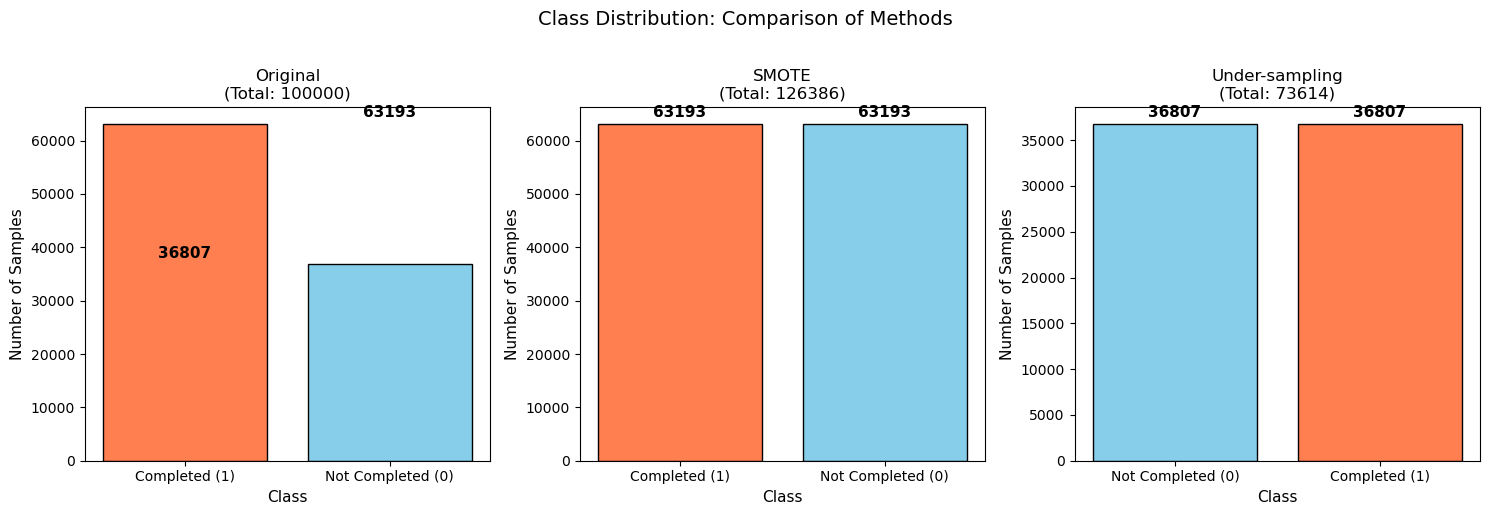

In [154]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = [
    ('Original', original_distribution),
    ('SMOTE', smote_distribution),
    ('Under-sampling', rus_distribution)
]

for idx, (method_name, distribution) in enumerate(methods):
    classes = list(distribution.keys())
    counts = list(distribution.values())
    
    axes[idx].bar(classes, counts, color=['skyblue', 'coral'], edgecolor='black')
    axes[idx].set_xlabel('Class', fontsize=11)
    axes[idx].set_ylabel('Number of Samples', fontsize=11)
    axes[idx].set_title(f'{method_name}\n(Total: {sum(counts)})', fontsize=12)
    axes[idx].set_xticks(classes)
    axes[idx].set_xticklabels(['Not Completed (0)', 'Completed (1)'])
    
    for i, count in enumerate(counts):
        axes[idx].text(i, count + max(counts)*0.02, str(count), 
                      ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Comparison of Methods', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### V. ML Models

In this section, five different machine learning models are evaluated using SMOTE-balanced data and 5-fold cross-validation. 
For each model, key performance metrics—including **accuracy, precision, recall, and F1-score**—are computed and compared. 
Additionally, a **Voting Classifier** is tested to combine predictions from multiple models and assess whether ensemble learning improves overall performance.


The selected models represent a diverse set of learning approaches, including linear models, distance-based methods, tree-based models, and ensemble techniques.

To address class imbalance, appropriate configurations such as `class_weight="balanced"` were applied where supported. 
Hyperparameters were chosen to control model complexity and reduce the risk of overfitting.

In addition to individual models, a **Voting Classifier** was created to combine the predictions of all base models using **soft voting**, which averages predicted class probabilities. 
This ensemble approach aims to leverage the strengths of multiple classifiers and potentially improve overall predictive performance.

All defined models were then stored in a single structure to allow systematic evaluation and comparison in subsequent cross-validation experiments.


In [159]:
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", n_jobs=-1),
    "LinearSVC": CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=1000), method="sigmoid", cv=3),
    "RandomForest": RandomForestClassifier(
        n_estimators=50,  # Reduced from 200
        random_state=42, 
        max_depth=10,  # Reduced from 15
        min_samples_split=20,  # Increased from 15
        min_samples_leaf=10,  # Increased from 5
        max_features="sqrt",
        n_jobs=-1  # Use all CPU cores
    ),
    "KNN": KNeighborsClassifier(n_neighbors=10, weights="distance", n_jobs=-1),  # Reduced from 15
    "DecisionTree": DecisionTreeClassifier(
        random_state=42, 
        max_depth=10,  # Reduced from 15
        min_samples_split=20,  # Increased from 15
        min_samples_leaf=10  # Increased from 5
    )
}

voting = VotingClassifier(
    estimators=[(name, clone(model)) for name, model in models.items()],
    voting="soft",
    n_jobs=-1  # Parallel voting
)

models["VotingClassifier"] = voting


#print(f"Models to test: {list(models.keys())}\n")

In the next step, a helper function was defined to extract continuous prediction scores from different types of models. 
If a model supports probability estimates, the predicted probability of the positive class is used; otherwise, the decision function output is extracted. 
These scores are required for computing evaluation metrics such as ROC-based measures and for consistent model comparison.

To evaluate model performance efficiently, **Stratified K-Fold cross-validation** was employed, ensuring that the class distribution is preserved across all folds. 
The number of folds was set to three in order to reduce computational cost while maintaining reliable performance estimates.

Cross-validation folds were then explicitly created using the SMOTE-balanced dataset. 
For each fold, separate training and validation subsets were generated and stored, allowing all models to be evaluated under identical conditions in subsequent steps.

In [160]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

In [164]:
n_folds = 3  # was initially 5, but had to reduce it to 3
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Create folds for SMOTE data
folds_smote = []
for train_idx, val_idx in skf.split(X_smote, y_smote):
    X_tr, X_va = X_smote.iloc[train_idx], X_smote.iloc[val_idx]
    y_tr, y_va = y_smote.iloc[train_idx], y_smote.iloc[val_idx]
    folds_smote.append((X_tr, y_tr, X_va, y_va))

Now, all selected machine learning models were trained and evaluated using the SMOTE-balanced dataset with stratified cross-validation. 
For each model, training and validation were performed independently on each fold to ensure a fair and robust assessment of performance.

During each fold, predictions and continuous scores were generated and used to compute multiple evaluation metrics, including **accuracy, precision, recall, F1-score, and ROC-AUC**. 
These metrics provide a comprehensive view of model performance, particularly in the presence of class imbalance.

After completing all folds, the mean and standard deviation of each metric were calculated to summarize model stability and generalization performance. 
ROC-related data were also stored to allow for later visualization and comparison of ROC curves across models.

Finally, the aggregated results were combined into a single table, enabling direct comparison of all models and supporting informed model selection.

In [165]:
summaries = []
roc_smote = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    start_time = time.time()
    
    rows = []
    roc_payload = []

    for fold_id, (X_tr, y_tr, X_va, y_va) in enumerate(folds_smote, start=1):
        m = clone(model)
        m.fit(X_tr, y_tr)

        y_pred = m.predict(X_va)
        y_score = get_scores(m, X_va)

        rows.append({
            "fold": fold_id,
            "accuracy": accuracy_score(y_va, y_pred),
            "precision": precision_score(y_va, y_pred, zero_division=0),
            "recall": recall_score(y_va, y_pred, zero_division=0),
            "f1": f1_score(y_va, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_va, y_score) if y_score is not None else np.nan
        })

        roc_payload.append((y_va, y_score))

    folds_df = pd.DataFrame(rows)
    summary = folds_df.drop(columns=["fold"]).agg(["mean", "std"]).round(4)
    summary.insert(0, "model", model_name)

    summaries.append(summary.reset_index().rename(columns={"index": "stat"}))
    roc_smote[model_name] = roc_payload
    
    elapsed = time.time() - start_time
    print(f"Completed in {elapsed:.1f}s")

results_smote = pd.concat(summaries, ignore_index=True)

print("\n" + "="*80)
print("MODEL PERFORMANCE RESULTS")
print("="*80)
print(results_smote)


Training LogReg...
Completed in 18.4s
Training LinearSVC...
Completed in 20.6s
Training RandomForest...
Completed in 2.4s
Training KNN...
Completed in 16.7s
Training DecisionTree...
Completed in 3.3s
Training VotingClassifier...
Completed in 44.4s

MODEL PERFORMANCE RESULTS
    stat             model  accuracy  precision  recall      f1  roc_auc
0   mean            LogReg    0.6589     0.6648  0.6412  0.6528   0.7189
1    std            LogReg    0.0021     0.0025  0.0027  0.0022   0.0013
2   mean         LinearSVC    0.6733     0.7136  0.5790  0.6393   0.7347
3    std         LinearSVC    0.0015     0.0025  0.0054  0.0029   0.0014
4   mean      RandomForest    0.6669     0.6766  0.6395  0.6575   0.7358
5    std      RandomForest    0.0005     0.0010  0.0030  0.0013   0.0001
6   mean               KNN    0.6430     0.6093  0.7973  0.6907   0.7153
7    std               KNN    0.0047     0.0036  0.0049  0.0041   0.0052
8   mean      DecisionTree    0.6230     0.6226  0.6250  0.6237   0.

### Best Model Identification

After evaluating all models using cross-validation, the mean performance metrics were extracted to facilitate model comparison. 
Only the average results were considered in order to focus on overall performance rather than fold-specific variations.

For each evaluation metric—**accuracy, precision, recall, F1-score, and ROC-AUC**—the model achieving the highest mean score was identified. 
This provides insight into which models perform best under different evaluation criteria.

Finally, the overall best model was selected based on the **F1-score**, as it represents a balanced measure of precision and recall and is particularly suitable for imbalanced classification problems. 

In [168]:
# Extract mean results only
mean_results = results_smote[results_smote['stat'] == 'mean'].copy()
mean_results = mean_results.drop(columns=['stat']).set_index('model')

'''
print("\nMean Performance per Model:")
print(mean_results)
'''

# Find best model for each metric
print("Best Model per Metric:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    best_model = mean_results[metric].idxmax()
    best_score = mean_results[metric].max()
    print(f"  {metric.upper()}: {best_model} (score: {best_score:.4f})")

# Overall best model (by F1-score)
best_overall = mean_results['f1'].idxmax()
best_f1 = mean_results['f1'].max()
print(f"\nBest Overall Model (by F1-score): {best_overall} (F1: {best_f1:.4f})")

Best Model per Metric:
  ACCURACY: VotingClassifier (score: 0.6850)
  PRECISION: LinearSVC (score: 0.7136)
  RECALL: KNN (score: 0.7973)
  F1: KNN (score: 0.6907)
  ROC_AUC: VotingClassifier (score: 0.7627)

Best Overall Model (by F1-score): KNN (F1: 0.6907)


The results show that different models perform best under different evaluation metrics, highlighting the trade-offs inherent in imbalanced classification problems.

The **Voting Classifier** achieved the highest **accuracy** and **ROC-AUC**, indicating strong overall predictive capability and good class-separation performance when combining multiple models. 
This suggests that ensemble learning is effective at capturing diverse patterns in the data.

The **LinearSVC** obtained the highest **precision**, meaning it produces fewer false positives and is more conservative when predicting course completion.

The **KNN** model achieved the highest **recall** and **F1-score**, indicating that it is most effective at identifying students who complete the course while maintaining a good balance between precision and recall. 
This makes KNN particularly suitable when correctly identifying positive cases is a priority.

Given the class imbalance and the importance of balancing false positives and false negatives, the **F1-score** was selected as the primary evaluation metric. 
Based on this criterion, **KNN was chosen as the overall best-performing model**.


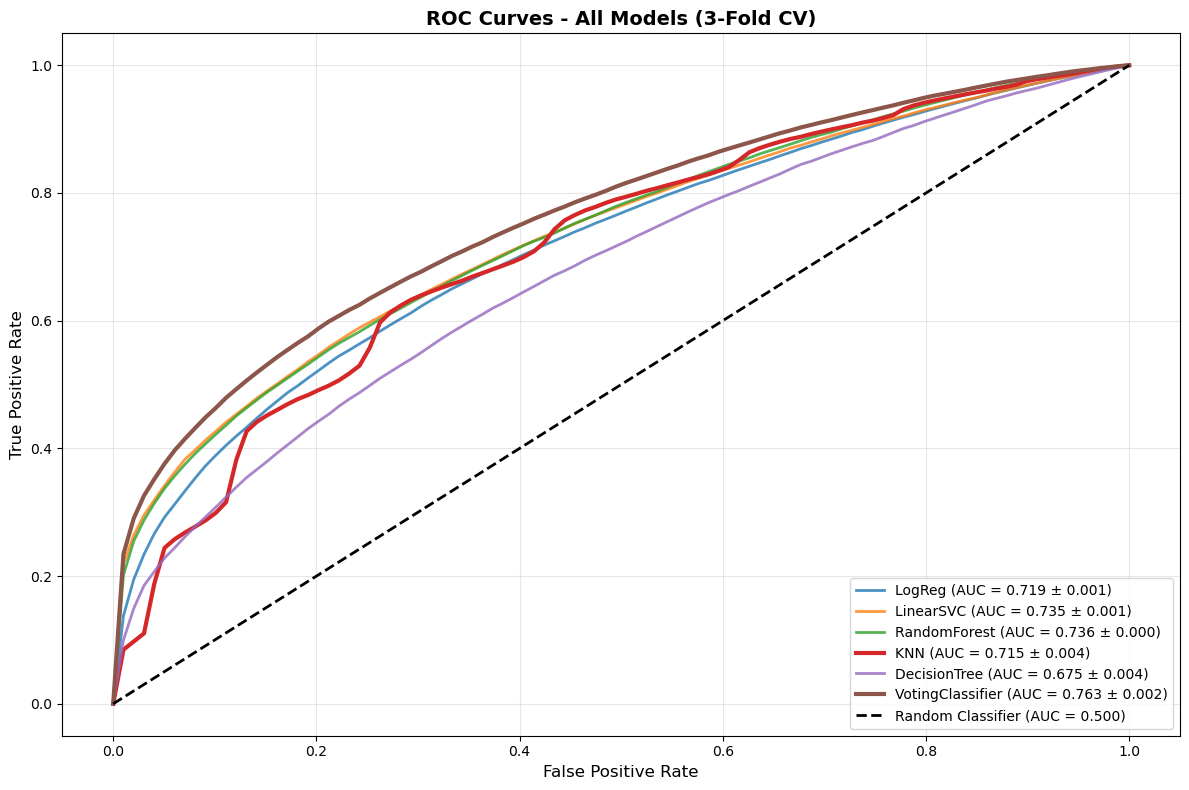

In [170]:
plt.figure(figsize=(12, 8))

for model_name, folds_data in roc_smote.items():
    # Calculate mean ROC curve across folds
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    for y_true, y_score in folds_data:
        if y_score is not None:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            aucs.append(auc(fpr, tpr))
    
    if len(aucs) > 0:
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        
        # Highlight best model and VotingClassifier
        if model_name == best_overall or model_name == 'VotingClassifier':
            linewidth = 3
            alpha = 1.0
        else:
            linewidth = 2
            alpha = 0.8
        
        plt.plot(mean_fpr, mean_tpr, linewidth=linewidth, alpha=alpha,
                label=f'{model_name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})')

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (3-Fold CV)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ROC Curve Analysis

This plot compares the ROC curves of all evaluated models using SMOTE-balanced data and 3-fold cross-validation. 
Each curve represents the average True Positive Rate versus False Positive Rate across folds, providing a robust estimate of model discrimination performance.

Models whose curves lie closer to the top-left corner demonstrate stronger class-separation ability. 
The **Voting Classifier** and **KNN** exhibit consistently higher ROC curves and larger AUC values compared to the other models, indicating superior overall discrimination performance.

The dashed diagonal line represents a random classifier (AUC = 0.5), serving as a baseline for comparison. 
All tested models perform substantially better than random guessing, confirming that meaningful predictive patterns are being captured.

Overall, the ROC analysis supports the earlier metric-based evaluation: ensemble methods achieve strong overall discrimination, while KNN maintains competitive performance and remains the preferred model when prioritizing balanced classification performance.


### VI. Conclusion

Using SMOTE-balanced data and stratified cross-validation, several machine learning models were evaluated to predict course completion. 
While ensemble methods such as the Voting Classifier achieved strong overall discrimination (highest ROC-AUC), **KNN achieved the best overall performance based on the F1-score**, indicating the most balanced trade-off between precision and recall. 
Linear models (Logistic Regression and Linear SVC) showed stable performance across folds, whereas tree-based and distance-based models exhibited greater variability.

Overall, the moderate performance scores suggest that predicting course completion from the available features remains challenging. 
This is likely due to overlapping behavioral patterns between students who complete and do not complete the course, as also reflected in the PCA and ROC analyses. 
Future improvements could include more extensive hyperparameter tuning, incorporating more expressive non-linear models (e.g. Gradient Boosting), refining feature engineering, and further investigating threshold optimization to better balance recall and precision.
